In [18]:
import numpy as np
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    precision_recall_curve, 
    average_precision_score
)

from sklearn.calibration import calibration_curve

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import AUC, Precision, Recall
from scikeras.wrappers import KerasClassifier
from fairlearn.reductions import ExponentiatedGradient, EqualizedOdds


In [19]:
df = pd.read_csv("df.csv")
df_nosens = pd.read_csv("df_nosens.csv")

In [20]:
df.head()

,los,gender,age_18-29,age_30-49,age_50-64,age_65-79,age_80-91,race_ASIAN,race_BLACK,race_EUROPEAN,...,lab_max_51006_missing,lab_max_51221_missing,lab_max_51222_missing,lab_max_51265_missing,lab_count_50912_missing,lab_count_51006_missing,lab_count_51221_missing,lab_count_51222_missing,lab_count_51265_missing,icu_mortality
0,0.410266,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0,1,1,1,0,0,1,1,1,0
1,3.893252,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
2,0.497535,0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,1,1,1,1,1,1,1,1,1,0
3,1.118032,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
4,0.948113,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0


### Multilayer Perceptron (MLP) 

##### Baseline Model

In [21]:
X = df_nosens.drop(columns=['icu_mortality'])
y = df_nosens['icu_mortality']

X_train_baseline, X_test_baseline, y_train_baseline, y_test_baseline = train_test_split(X, y, test_size=0.2, stratify=y, random_state=35)

scaler = StandardScaler()
X_train_baseline_scaled = scaler.fit_transform(X_train_baseline)
X_test_baseline_scaled = scaler.transform(X_test_baseline)


baseline_mlp = Sequential([
    Input(shape=(X_train_baseline_scaled.shape[1],)),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])


baseline_mlp.compile(optimizer='adam', 
                     loss='binary_crossentropy', 
                     metrics=['accuracy', AUC(name='auc'), Precision(name='precision'), Recall(name='recall')]
)

early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=10,
    restore_best_weights=True, # model.predict() uses the weights from the best epoch
    verbose=1
)

baseline_mlp.fit(X_train_baseline_scaled, 
                 y_train_baseline, 
                 epochs=100, 
                 batch_size=256, 
                 validation_split=0.2,
                 callbacks=[early_stop],
                 verbose=1
)


y_proba_baseline = baseline_mlp.predict(X_test_baseline_scaled).flatten()

best_f1_baseline = 0
best_thresh_baseline = 0
for t in np.arange(0.1, 0.9, 0.05):
    y_pred_baseline = (y_proba_baseline >= t).astype(int)
    precision = precision_score(y_test_baseline, y_pred_baseline)
    recall = recall_score(y_test_baseline, y_pred_baseline)
    f1 = f1_score(y_test_baseline, y_pred_baseline)
    print(f"Threshold: {t:.2f} -> Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}")

    if f1 > best_f1_baseline:
        best_f1_baseline = f1
        best_thresh_baseline = t

print(f"\nBest F1-score: {best_f1_baseline:.4f} at threshold = {best_thresh_baseline:.2f}")

Epoch 1/100
237/237 [==============================] - 2s 4ms/step - loss: 0.2162 - accuracy: 0.9300 - auc: 0.8387 - precision: 0.7042 - recall: 0.2513 - val_loss: 0.1638 - val_accuracy: 0.9465 - val_auc: 0.9086 - val_precision: 0.8291 - val_recall: 0.4435
Epoch 2/100
237/237 [==============================] - 1s 3ms/step - loss: 0.1734 - accuracy: 0.9429 - auc: 0.9020 - precision: 0.8014 - recall: 0.4038 - val_loss: 0.1531 - val_accuracy: 0.9473 - val_auc: 0.9212 - val_precision: 0.8378 - val_recall: 0.4475
Epoch 3/100
237/237 [==============================] - 1s 3ms/step - loss: 0.1608 - accuracy: 0.9460 - auc: 0.9137 - precision: 0.8287 - recall: 0.4305 - val_loss: 0.1507 - val_accuracy: 0.9480 - val_auc: 0.9256 - val_precision: 0.7936 - val_recall: 0.4996
Epoch 4/100
237/237 [==============================] - 1s 4ms/step - loss: 0.1560 - accuracy: 0.9478 - auc: 0.9184 - precision: 0.8346 - recall: 0.4531 - val_loss: 0.1445 - val_accuracy: 0.9502 - val_auc: 0.9298 - val_precision: 

#### Full Model

In [22]:
X = df.drop(columns=['icu_mortality'])
y = df['icu_mortality']


X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=35
)


scaler = StandardScaler()
X_train_full_scaled = scaler.fit_transform(X_train_full)
X_test_full_scaled = scaler.transform(X_test_full)


full_mlp = Sequential([
    Input(shape=(X_train_full_scaled.shape[1],)),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

full_mlp.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', AUC(name='auc'), Precision(name='precision'), Recall(name='recall')]
)


early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)


full_mlp.fit(
    X_train_full_scaled,
    y_train_full,
    epochs=100,
    batch_size=256,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)


y_proba_full = full_mlp.predict(X_test_full_scaled).flatten()

best_f1_full = 0
best_thresh_full = 0
for t in np.arange(0.1, 0.9, 0.05):
    y_pred_full = (y_proba_full >= t).astype(int)
    precision = precision_score(y_test_full, y_pred_full)
    recall = recall_score(y_test_full, y_pred_full)
    f1 = f1_score(y_test_full, y_pred_full)
    print(f"Threshold: {t:.2f} -> Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}")

    if f1 > best_f1_full:
        best_f1_full = f1
        best_thresh_full = t

print(f"\nBest F1-score: {best_f1_full:.4f} at threshold = {best_thresh_full:.2f}")


Epoch 1/100
237/237 [==============================] - 2s 4ms/step - loss: 0.2434 - accuracy: 0.9136 - auc: 0.8047 - precision: 0.4304 - recall: 0.1667 - val_loss: 0.1719 - val_accuracy: 0.9458 - val_auc: 0.9000 - val_precision: 0.8664 - val_recall: 0.4058
Epoch 2/100
237/237 [==============================] - 1s 3ms/step - loss: 0.1809 - accuracy: 0.9418 - auc: 0.8952 - precision: 0.7803 - recall: 0.4036 - val_loss: 0.1529 - val_accuracy: 0.9473 - val_auc: 0.9227 - val_precision: 0.8606 - val_recall: 0.4306
Epoch 3/100
237/237 [==============================] - 1s 3ms/step - loss: 0.1636 - accuracy: 0.9459 - auc: 0.9145 - precision: 0.8131 - recall: 0.4424 - val_loss: 0.1473 - val_accuracy: 0.9492 - val_auc: 0.9282 - val_precision: 0.8496 - val_recall: 0.4667
Epoch 4/100
237/237 [==============================] - 1s 3ms/step - loss: 0.1580 - accuracy: 0.9477 - auc: 0.9216 - precision: 0.8130 - recall: 0.4694 - val_loss: 0.1441 - val_accuracy: 0.9508 - val_auc: 0.9327 - val_precision: 

=== Baseline Model (No Sensitive Features) ===
              precision    recall  f1-score   support

           0       0.97      0.98      0.98     17339
           1       0.77      0.63      0.69      1550

    accuracy                           0.95     18889
   macro avg       0.87      0.81      0.83     18889
weighted avg       0.95      0.95      0.95     18889

AUC: 0.944221622335626

=== Full Model (With Sensitive Features) ===
              precision    recall  f1-score   support

           0       0.97      0.98      0.97     17339
           1       0.75      0.64      0.70      1550

    accuracy                           0.95     18889
   macro avg       0.86      0.81      0.84     18889
weighted avg       0.95      0.95      0.95     18889

AUC: 0.9442951094772367


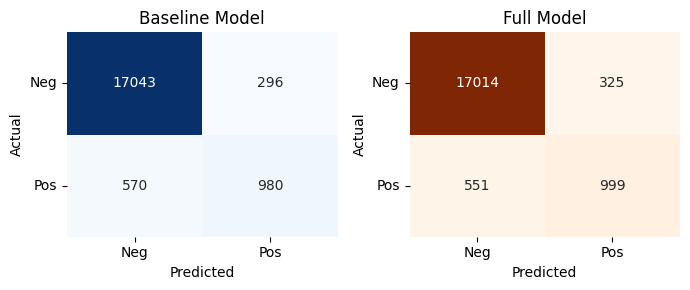

In [23]:
y_pred_baseline = (y_proba_baseline >= best_thresh_baseline).astype(int)
print("=== Baseline Model (No Sensitive Features) ===")
print(classification_report(y_test_baseline, y_pred_baseline))
print("AUC:", roc_auc_score(y_test_baseline, y_proba_baseline))


y_pred_full = (y_proba_full >= best_thresh_full).astype(int)
print("\n=== Full Model (With Sensitive Features) ===")
print(classification_report(y_test_full, y_pred_full))
print("AUC:", roc_auc_score(y_test_full, y_proba_full))


cm_baseline = confusion_matrix(y_test_baseline, y_pred_baseline)
cm_full = confusion_matrix(y_test_full, y_pred_full)


fig, axs = plt.subplots(1, 2, figsize=(7, 3))
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axs[0])
axs[0].set_title('Baseline Model')
axs[0].set_xlabel('Predicted')
axs[0].set_ylabel('Actual')
axs[0].set_xticklabels(['Neg', 'Pos'])
axs[0].set_yticklabels(['Neg', 'Pos'], rotation=0)


sns.heatmap(cm_full, annot=True, fmt='d', cmap='Oranges', cbar=False, ax=axs[1])
axs[1].set_title('Full Model')
axs[1].set_xlabel('Predicted')
axs[1].set_ylabel('Actual')
axs[1].set_xticklabels(['Neg', 'Pos'])
axs[1].set_yticklabels(['Neg', 'Pos'], rotation=0)

plt.tight_layout()
plt.show()

### Fairness Diagnosis

In [24]:
def create_df_test(df, X_test, y_true, y_pred, y_score):
    df_test = df.loc[X_test.index].copy()
    df_test['y_true'] = y_true
    df_test['y_pred'] = y_pred
    df_test['y_score'] = y_score.clip(0, 1)

    gender_map = {1: 'Male', 0: 'Female'}
    age_cols = ['age_18-29', 'age_30-49', 'age_50-64', 'age_65-79', 'age_80-91']
    race_cols = ['race_ASIAN', 'race_BLACK', 'race_EUROPEAN', 'race_HISPANIC/LATINO',
                'race_OTHER', 'race_RUSSIAN', 'race_UNKNOWN', 'race_WHITE']
    
    df_test['gender_group'] = df_test['gender'].map(gender_map)
    df_test['age_group'] = df_test[age_cols].idxmax(axis=1).str.replace('age_', '')
    df_test['race_group'] = df_test[race_cols].idxmax(axis=1).str.replace('race_', '')

    return df_test

df_test_full = create_df_test(df, X_test_full, y_test_full, y_pred_full, y_proba_full)
df_test_baseline = create_df_test(df, X_test_baseline, y_test_baseline, y_pred_baseline, y_proba_baseline)


def get_group_metrics(df_subset, group_col):
    metrics_list = []
    for group in df_subset[group_col].unique():
        group_df = df_subset[df_subset[group_col] == group]
        report = classification_report(
            group_df['y_true'], group_df['y_pred'],
            output_dict=True, zero_division=0
        )
        tn, fp, fn, tp = confusion_matrix(group_df['y_true'], group_df['y_pred']).ravel()
        metrics_list.append({
            'group': group,
            'support': report['1']['support'],
            'precision': report['1']['precision'],
            'recall (TPR)': report['1']['recall'],
            'f1_score': report['1']['f1-score'],
            'FPR': fp / (fp + tn) if (fp + tn) > 0 else 0.0,
            'PPR': group_df['y_pred'].mean()
        })
    return pd.DataFrame(metrics_list)

gender_report_full = get_group_metrics(df_test_full, 'gender_group')
age_report_full = get_group_metrics(df_test_full, 'age_group')
race_report_full = get_group_metrics(df_test_full, 'race_group')

gender_report_baseline = get_group_metrics(df_test_baseline, 'gender_group')
age_report_baseline = get_group_metrics(df_test_baseline, 'age_group')
race_report_baseline = get_group_metrics(df_test_baseline, 'race_group')

In [25]:
gender_report_full['model'] = 'Full'
age_report_full['model'] = 'Full'
race_report_full['model'] = 'Full'

gender_report_baseline['model'] = 'Baseline'
age_report_baseline['model'] = 'Baseline'
race_report_baseline['model'] = 'Baseline'

gender_comparison = pd.concat([gender_report_full, gender_report_baseline])
age_comparison = pd.concat([age_report_full, age_report_baseline])
race_comparison = pd.concat([race_report_full, race_report_baseline])

gender_comparison
age_comparison
race_comparison

,group,support,precision,recall (TPR),f1_score,FPR,PPR,model
0,WHITE,867.0,0.775540,0.621684,0.690141,0.014244,0.058804,Full
1,OTHER,61.0,0.693548,0.704918,0.699187,0.025099,0.075795,Full
2,UNKNOWN,329.0,0.786942,0.696049,0.738710,0.032839,0.131258,Full
3,BLACK,141.0,0.666667,0.609929,0.637037,0.022108,0.061841,Full
4,HISPANIC/LATINO,52.0,0.720000,0.692308,0.705882,0.022117,0.072993,Full
5,ASIAN,53.0,0.727273,0.754717,0.740741,0.029014,0.096491,Full
6,EUROPEAN,29.0,0.538462,0.482759,0.509091,0.024691,0.050485,Full
7,RUSSIAN,18.0,0.750000,0.666667,0.705882,0.024845,0.089385,Full
0,WHITE,867.0,0.774194,0.636678,0.698734,0.014701,0.060327,Baseline
1,OTHER,61.0,0.724138,0.688525,0.705882,0.021136,0.070905,Baseline


#### Equal Opportunity

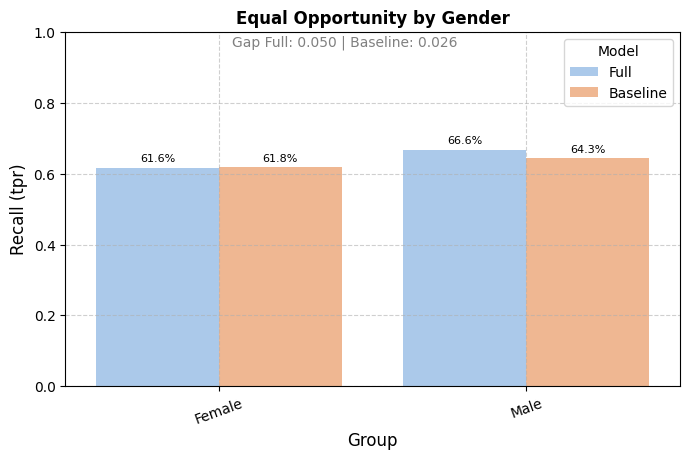

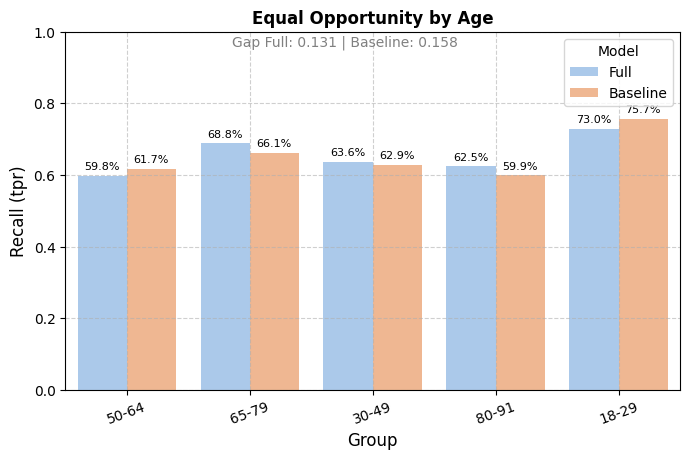

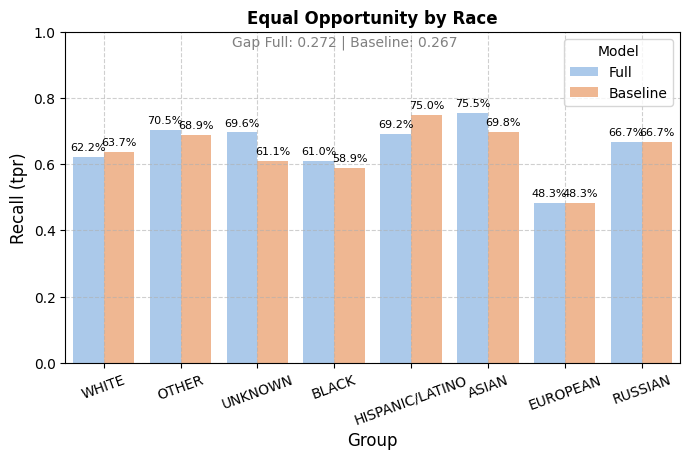

In [26]:
def plot_equal_opportunity(df, metric='recall (TPR)', title='', figsize=(7, 5)):
    plt.figure(figsize=figsize)
    
    # subtitle
    gap_dict = {}
    for model in df['model'].unique():
        group_df = df[df['model'] == model]
        gap = group_df[metric].max() - group_df[metric].min()
        gap_dict[model] = gap
    
    subtitle = "Gap " + " | ".join([f"{model}: {gap:.3f}" for model, gap in gap_dict.items()])

    
    ax = sns.barplot(data=df, x='group', y=metric, hue='model', palette='pastel')
    ax.set_ylim(0, 1)
    ax.set_title(title, fontsize=12, fontweight='bold')
    plt.suptitle(subtitle, fontsize=10, y=0.86, color='gray')

    ax.set_ylabel(metric.capitalize(), fontsize=12)
    ax.set_xlabel('Group', fontsize=12)
    plt.xticks(rotation=20)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(title='Model')

    # Annotate each bar
    for container in ax.containers:
        for bar in container:
            height = bar.get_height()
            if not np.isnan(height):
                ax.annotate(f'{height:.1%}',
                            xy=(bar.get_x() + bar.get_width() / 2, height),
                            xytext=(0, 3),
                            textcoords='offset points',
                            ha='center', va='bottom',
                            fontsize=8, color='black')

    plt.tight_layout()
    plt.show()

    return gap_dict


eo_gender_dict = plot_equal_opportunity(gender_comparison, metric='recall (TPR)', title='Equal Opportunity by Gender')
eo_age_dict = plot_equal_opportunity(age_comparison, metric='recall (TPR)', title='Equal Opportunity by Age')
eo_race_dict = plot_equal_opportunity(race_comparison, metric='recall (TPR)', title='Equal Opportunity by Race')


#### Statistical Parity

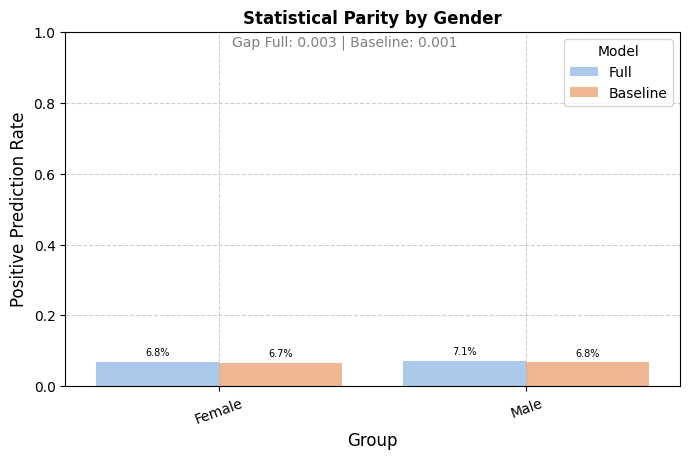

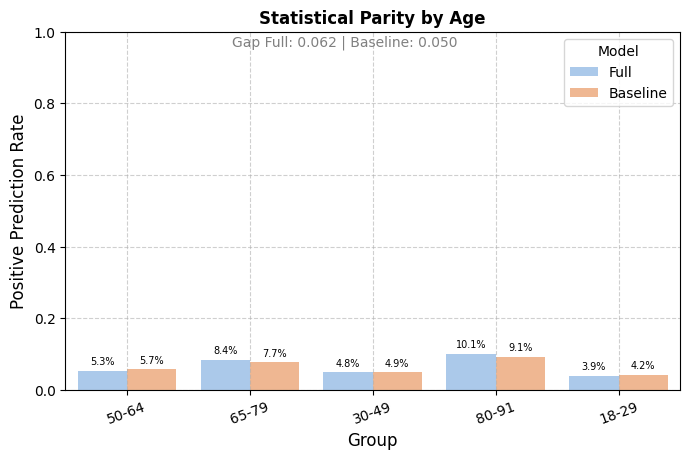

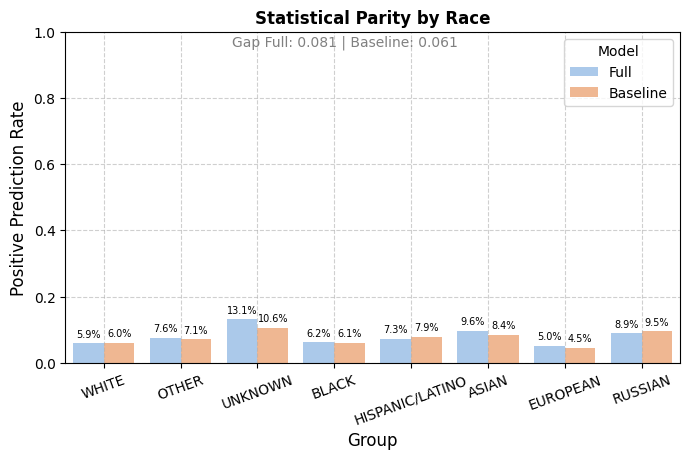

In [27]:


def plot_statistical_parity(df, title='', figsize=(7, 5)):
    plt.figure(figsize=figsize)
    
    # subtitle
    gap_texts = []
    gap_dict = {}
    for model in df['model'].unique():
        group_df = df[df['model'] == model]
        gap = group_df['PPR'].max() - group_df['PPR'].min()
        gap_texts.append(f"{model}: {gap:.3f}")
        gap_dict[model] = gap

    subtitle = "Gap " + " | ".join(gap_texts)


    ax = sns.barplot(data=df, x='group', y='PPR', hue='model', palette='pastel')
    ax.set_ylim(0, 1)
    ax.set_title(title, fontsize=12, fontweight='bold')
    plt.suptitle(subtitle, fontsize=10, y=0.86, color='gray')

    ax.set_ylabel('Positive Prediction Rate', fontsize=12)
    ax.set_xlabel('Group', fontsize=12)
    plt.xticks(rotation=20)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(title='Model')

    # Annotate each bar
    for container in ax.containers:
        for bar in container:
            height = bar.get_height()
            if not np.isnan(height):
                ax.annotate(f'{height:.1%}',
                            xy=(bar.get_x() + bar.get_width() / 2, height),
                            xytext=(0, 3),
                            textcoords='offset points',
                            ha='center', va='bottom',
                            fontsize=7, color='black')

    plt.tight_layout()
    plt.show()

    return gap_dict

gender_ppr_dict = plot_statistical_parity(df=gender_comparison, title='Statistical Parity by Gender')
age_ppr_dict = plot_statistical_parity(df=age_comparison, title='Statistical Parity by Age')
race_ppr_dict = plot_statistical_parity(df=race_comparison, title='Statistical Parity by Race')


#### Equalized Odds

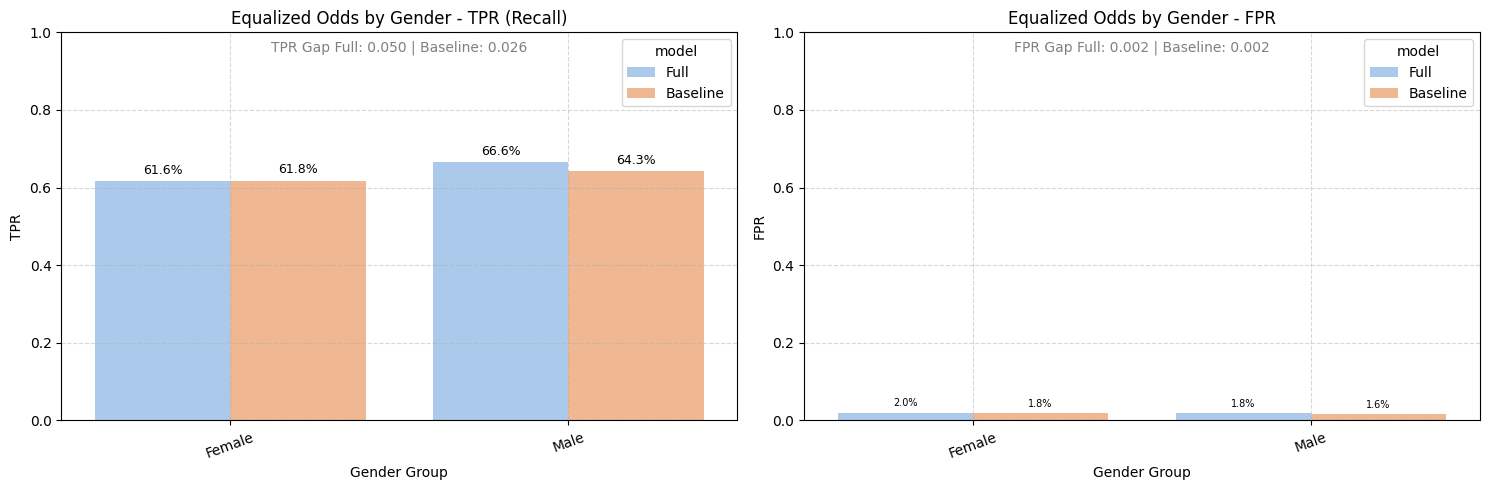

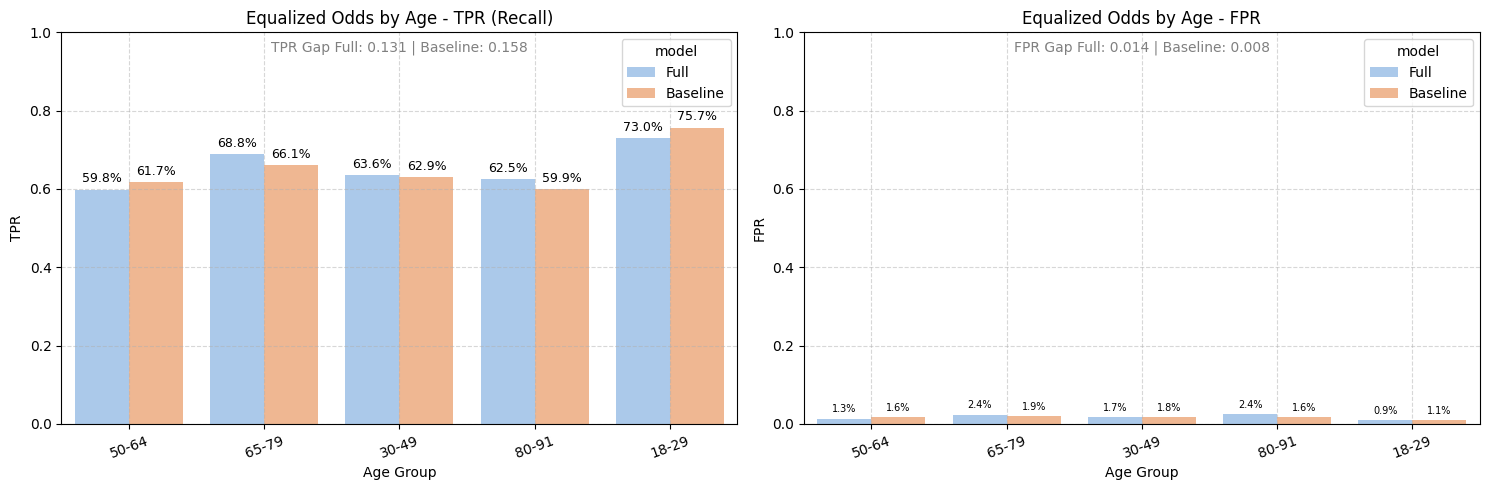

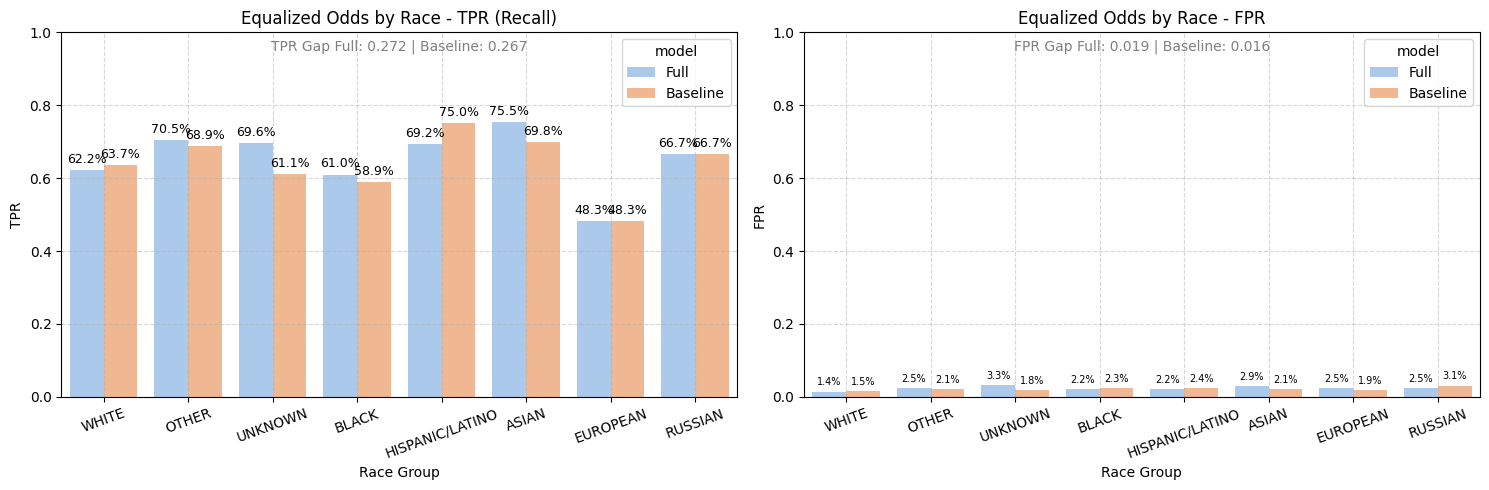

In [28]:
def plot_equalized_odds(df, group_col_name, title_prefix, figsize=(15, 5)):
    fig, axs = plt.subplots(1, 2, figsize=figsize, sharey=False)

    # subtitles
    tpr_gap_texts = []
    fpr_gap_texts = []
    tpr_gap_dict = {}
    fpr_gap_dict = {}

    for model in df['model'].unique():
        model_df = df[df['model'] == model]
        tpr_gap = model_df['recall (TPR)'].max() - model_df['recall (TPR)'].min()
        fpr_gap = model_df['FPR'].max() - model_df['FPR'].min()
        tpr_gap_texts.append(f"{model}: {tpr_gap:.3f}")
        fpr_gap_texts.append(f"{model}: {fpr_gap:.3f}")
        tpr_gap_dict[model] = tpr_gap
        fpr_gap_dict[model] = fpr_gap


    axs[0].text(0.5, 0.95, "TPR Gap " + " | ".join(tpr_gap_texts),
                fontsize=10, color='gray', ha='center', transform=axs[0].transAxes)

    axs[1].text(0.5, 0.95, "FPR Gap " + " | ".join(fpr_gap_texts),
                fontsize=10, color='gray', ha='center', transform=axs[1].transAxes)


    # TPR
    sns.barplot(data=df, x='group', y='recall (TPR)', hue='model', palette='pastel', ax=axs[0])
    axs[0].set_title(f'{title_prefix} - TPR (Recall)', fontsize=12)
    axs[0].set_xlabel(group_col_name)
    axs[0].tick_params(axis='x', rotation=20)
    axs[0].set_ylabel('TPR')
    axs[0].set_ylim(0, 1)
    axs[0].grid(True, linestyle='--', alpha=0.5)

    # Annotate the bar
    for container in axs[0].containers:
        for bar in container:
            height = bar.get_height()
            if not np.isnan(height):
                axs[0].annotate(f'{height:.1%}', xy=(bar.get_x() + bar.get_width() / 2, height),
                                xytext=(0, 3), textcoords='offset points',
                                ha='center', va='bottom', fontsize=9)

    # FPR
    sns.barplot(data=df, x='group', y='FPR', hue='model', palette='pastel', ax=axs[1])
    axs[1].set_title(f'{title_prefix} - FPR', fontsize=12)
    axs[1].set_xlabel(group_col_name)
    axs[1].tick_params(axis='x', rotation=20)
    axs[1].set_ylabel('FPR')
    axs[1].set_ylim(0, 1)
    axs[1].grid(True, linestyle='--', alpha=0.5)

    # Annotate the bar
    for container in axs[1].containers:
        for bar in container:
            height = bar.get_height()
            if not np.isnan(height):
                axs[1].annotate(f'{height:.1%}', xy=(bar.get_x() + bar.get_width() / 2, height),
                                xytext=(0, 3), textcoords='offset points',
                                ha='center', va='bottom', fontsize=7)

    plt.tight_layout()
    plt.show()

    return tpr_gap_dict, fpr_gap_dict

gender_tpr_dict, gender_fpr_dict = plot_equalized_odds(gender_comparison, group_col_name='Gender Group', title_prefix='Equalized Odds by Gender')
age_tpr_dict, age_fpr_dict = plot_equalized_odds(age_comparison, group_col_name='Age Group', title_prefix='Equalized Odds by Age')
race_tpr_dict, race_fpr_dict = plot_equalized_odds(race_comparison, group_col_name='Race Group', title_prefix='Equalized Odds by Race')

#### Calibration

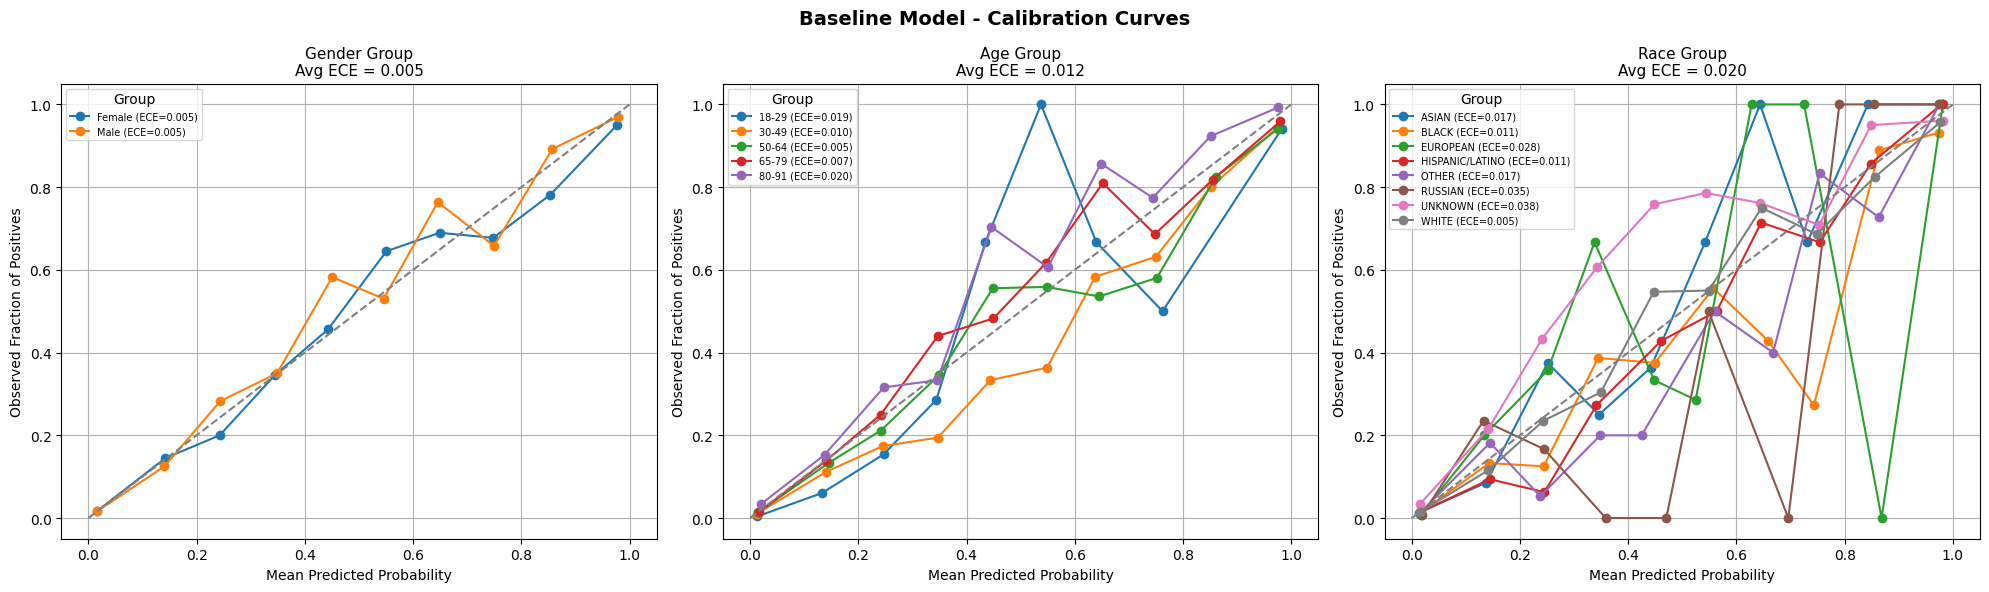

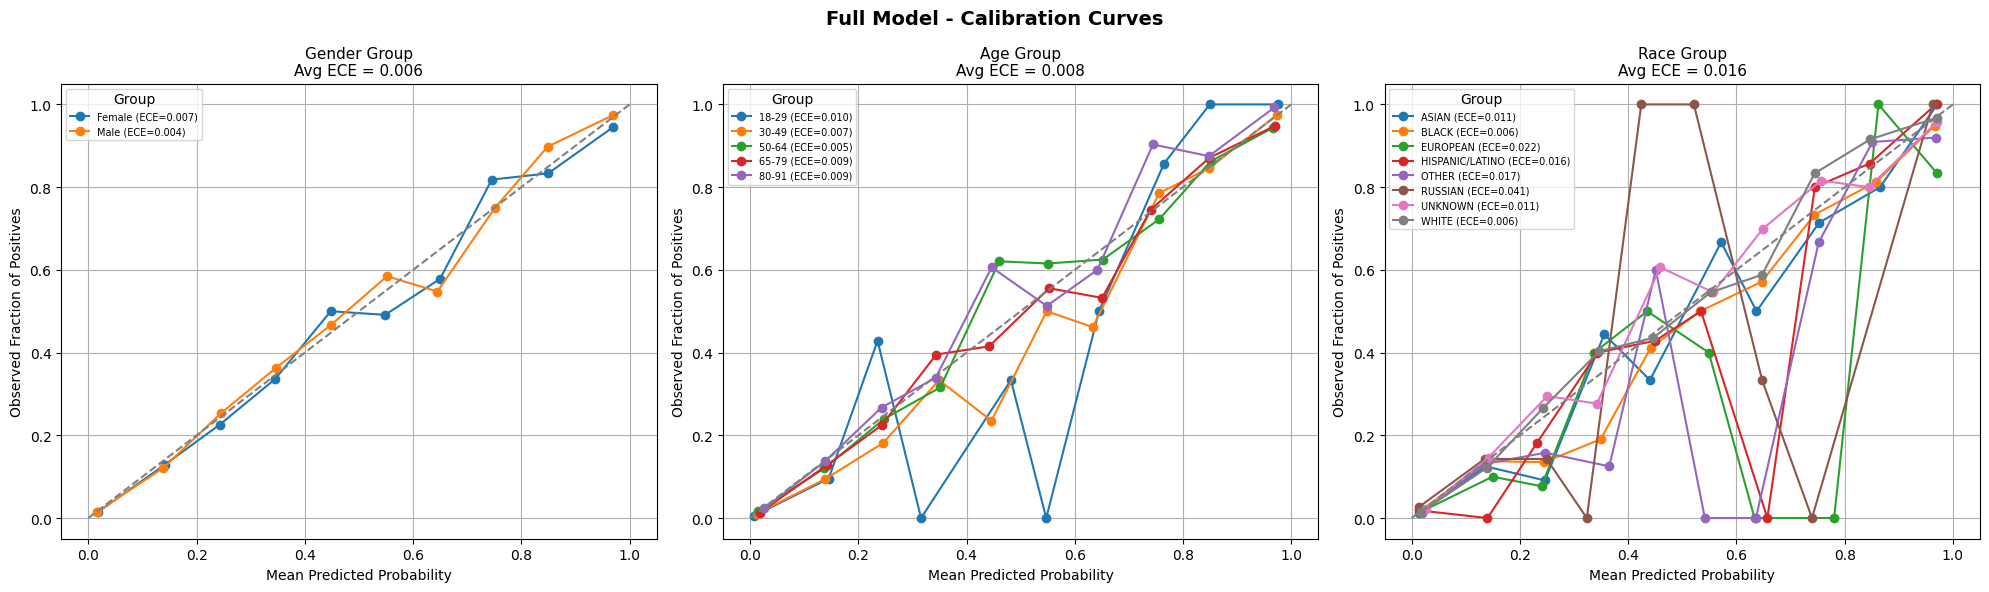

In [29]:
def compute_ece(y_true, y_score, n_bins=10):
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_indices = np.digitize(y_score, bins) - 1
    ece = 0.0

    for i in range(n_bins):
        mask = bin_indices == i
        if np.any(mask):
            bin_confidence = y_score[mask].mean()
            bin_accuracy = y_true[mask].mean()
            bin_size = mask.sum() / len(y_true)
            ece += bin_size * np.abs(bin_confidence - bin_accuracy)
    
    return ece

def plot_calibration_ece(df, model_label, n_bins=10, figsize=(15, 5)):
    fig, axs = plt.subplots(1, 3, figsize=figsize)

    group_cols = ['gender_group', 'age_group', 'race_group']
    titles = ['Gender Group', 'Age Group', 'Race Group']
    avg_subgroup_ece = {}

    for i, (group_col, title) in enumerate(zip(group_cols, titles)):
        ax = axs[i]
        group_df = df
        subgroups = sorted(group_df[group_col].unique())

        subgroup_ece_list = []
        subgroup_labels = []
        

        for subgroup in subgroups:
            subgroup_df = group_df[group_df[group_col] == subgroup]
            y_true = subgroup_df['y_true']
            y_score = subgroup_df['y_score']
            
            subgroup_ece = compute_ece(y_true, y_score)
            subgroup_ece_list.append(subgroup_ece)
            
            prob_true, prob_pred = calibration_curve(y_true, y_score, n_bins=n_bins, strategy='uniform')
            ax.plot(prob_pred, prob_true, marker='o')
            subgroup_labels.append(f'{subgroup} (ECE={subgroup_ece:.3f})')

        
        avg_subgroup_ece[group_col] = np.mean(subgroup_ece_list)


        ax.plot([0, 1], [0, 1], linestyle='--', color='gray')
        ax.set_xlabel('Mean Predicted Probability')
        ax.set_ylabel('Observed Fraction of Positives')
        ax.set_title(f'{title}\nAvg ECE = {avg_subgroup_ece[group_col]:.3f}', fontsize=11)
        ax.grid(True)
        ax.legend(subgroup_labels, fontsize=7, title='Group')

    plt.suptitle(f'{model_label} Model - Calibration Curves', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return avg_subgroup_ece

df_list = [df_test_baseline, df_test_full]
model_label = ['Baseline', 'Full']
avg_subgroup_ece = {}
for df_l, model_l in zip(df_list, model_label):
    avg_subgroup_ece[model_l] = plot_calibration_ece(df=df_l, model_label = model_l, figsize=(20, 6))


#### Bias Mitigation1
```
          X (Input Features)
                │
        ┌───────▼────────┐
        │    Apply SMOTE │  ← Balance class distribution (e.g., mortality = 1)
        └───────┬────────┘
                ▼
        X_smote, y_smote
                │
        ┌───────▼────────┐
        │ Compute Weights│
        └───────┬────────┘
                ▼
         ┌──────▼──────┐
         │    MLP      │  ← Standard multilayer perceptron
         └──────┬──────┘
                ▼
             y_pred
         (ICU Mortality)
```


In [30]:
df_dummy = df.copy()

age_cols = ['age_18-29', 'age_30-49', 'age_50-64',   'age_65-79', 'age_80-91']
race_cols = ['race_ASIAN', 'race_BLACK', 'race_EUROPEAN', 'race_HISPANIC/LATINO',
             'race_OTHER', 'race_RUSSIAN', 'race_UNKNOWN', 'race_WHITE']

df_dummy['age_group'] = df_dummy[age_cols].idxmax(axis=1).str.replace('age_', '')
df_dummy['race_group'] = df_dummy[race_cols].idxmax(axis=1).str.replace('race_', '')
df_dummy['gender_group'] = df_dummy['gender'].map({0: 'Female', 1: 'Male'})

# reweighting intersection group (gender, age, race)
df_dummy['gender_race_age'] = df_dummy[['gender', 'race_group', 'age_group']].astype(str).agg(','.join, axis=1)
group_counts = df_dummy['gender_race_age'].value_counts()
group_weights = 1 / group_counts
group_weights = group_weights / group_weights.sum()
df_dummy['group_weight'] = df_dummy['gender_race_age'].map(group_weights) 
df_dummy

,los,gender,age_18-29,age_30-49,age_50-64,age_65-79,age_80-91,race_ASIAN,race_BLACK,race_EUROPEAN,...,lab_count_51006_missing,lab_count_51221_missing,lab_count_51222_missing,lab_count_51265_missing,icu_mortality,age_group,race_group,gender_group,gender_race_age,group_weight
0,0.410266,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0,1,1,1,0,50-64,WHITE,Female,"0,WHITE,50-64",0.000088
1,3.893252,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,0,0,80-91,WHITE,Female,"0,WHITE,80-91",0.000106
2,0.497535,0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,1,1,1,1,0,65-79,BLACK,Female,"0,BLACK,65-79",0.000369
3,1.118032,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,50-64,WHITE,Female,"0,WHITE,50-64",0.000088
4,0.948113,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,50-64,WHITE,Female,"0,WHITE,50-64",0.000088
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94439,6.950370,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,30-49,WHITE,Male,"1,WHITE,30-49",0.000146
94440,0.960741,1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,0,0,80-91,WHITE,Male,"1,WHITE,80-91",0.000114
94441,1.790995,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,30-49,WHITE,Female,"0,WHITE,30-49",0.000188
94442,5.297766,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,1,50-64,WHITE,Male,"1,WHITE,50-64",0.000057


In [31]:
X = df.drop(columns=['icu_mortality'])
y = df['icu_mortality']
sens = df_dummy['gender_race_age']
le = LabelEncoder()
sens = pd.Series(le.fit_transform(sens), name='gender_race_age')
Xys = pd.concat([X, y, sens], axis=1)

# Apply SMOTE on X and y Resample s
smote = SMOTE(random_state=35)
X_resampled, y_resampled = smote.fit_resample(Xys.drop(columns=['icu_mortality', 'gender_race_age']), Xys['icu_mortality'])

# Assign sensitive attributes by randomly copying from the original minority class instances
n_original = len(Xys)
n_resampled = len(X_resampled)
n_diff = n_resampled - n_original
minority_indices = Xys[Xys['icu_mortality'] == 1].index
np.random.seed(35)
new_indices = np.random.choice(minority_indices, size=n_diff, replace=True)
s_resampled = np.concatenate([Xys['gender_race_age'].values, Xys.loc[new_indices, 'gender_race_age'].values])

# Reconstruct the resampled DataFrame
df_resampled = pd.concat([
    pd.DataFrame(X_resampled, columns=X.columns).reset_index(drop=True),
    pd.Series(y_resampled, name='icu_mortality').reset_index(drop=True),
    pd.Series(s_resampled, name='gender_race_age').reset_index(drop=True)
], axis=1)


X = df_resampled.drop(columns=['icu_mortality', 'gender_race_age'])
y = df_resampled['icu_mortality']
sens = df_resampled['gender_race_age']
X_train_bm1, X_test_bm1, y_train_bm1, y_test_bm1, s_train_bm1, s_test_bm1 = train_test_split(X, y, sens, test_size=0.2, stratify=y, random_state=35)


# Manual group × label reweighting
sy = list(zip(s_train_bm1, y_train_bm1))
pair_counts = Counter(sy)
sample_weights = np.array([1.0 / pair_counts[(s, y)] for s, y in sy])


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bm1)
X_test_scaled = scaler.transform(X_test_bm1)


bm1_mlp = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

bm1_mlp.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', AUC(name='auc'), Precision(), Recall()],
    weighted_metrics=[]  # Suppresses warning for sample-weighted validation metrics
)


early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# Train the model with reweighting
bm1_mlp.fit(
    X_train_scaled,
    y_train_bm1,
    epochs=100,
    batch_size=256,
    validation_split=0.2,
    sample_weight=sample_weights,
    callbacks=[early_stop],
    verbose=1
)


y_proba_bm1 = bm1_mlp.predict(X_test_scaled).flatten()
best_f1_bm1, best_thresh_bm1 = 0, 0
for t in np.arange(0.1, 0.9, 0.05):
    y_pred_bm1 = (y_proba_bm1 >= t).astype(int)
    precision = precision_score(y_test_bm1, y_pred_bm1)
    recall = recall_score(y_test_bm1, y_pred_bm1)
    f1 = f1_score(y_test_bm1, y_pred_bm1)
    print(f"Threshold: {t:.2f} -> Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}")
    if f1 > best_f1_bm1:
        best_f1_bm1, best_thresh_bm1 = f1, t

print(f"\nBest F1-score: {best_f1_bm1:.4f} at threshold = {best_thresh_bm1:.2f}")


y_pred_bm1 = (y_proba_bm1 >= best_thresh_bm1).astype(int)
print("\n=== bm1 SMOTE + Reweighting ===")
print(classification_report(y_test_bm1, y_pred_bm1))
print("AUC:", roc_auc_score(y_test_bm1, y_proba_bm1))

Epoch 1/100
434/434 [==============================] - 3s 4ms/step - loss: 4.1844e-04 - accuracy: 0.7266 - auc: 0.8292 - precision_1: 0.6826 - recall_1: 0.8466 - val_loss: 3.4167e-04 - val_accuracy: 0.7671 - val_auc: 0.8968 - val_precision_1: 0.7061 - val_recall_1: 0.9169
Epoch 2/100
434/434 [==============================] - 1s 3ms/step - loss: 3.2053e-04 - accuracy: 0.7866 - auc: 0.8940 - precision_1: 0.7361 - recall_1: 0.8932 - val_loss: 3.0375e-04 - val_accuracy: 0.8059 - val_auc: 0.9131 - val_precision_1: 0.7570 - val_recall_1: 0.9022
Epoch 3/100
434/434 [==============================] - 1s 3ms/step - loss: 2.9157e-04 - accuracy: 0.8078 - auc: 0.9094 - precision_1: 0.7581 - recall_1: 0.9037 - val_loss: 2.8535e-04 - val_accuracy: 0.8204 - val_auc: 0.9282 - val_precision_1: 0.7637 - val_recall_1: 0.9290
Epoch 4/100
434/434 [==============================] - 1s 2ms/step - loss: 2.5858e-04 - accuracy: 0.8233 - auc: 0.9215 - precision_1: 0.7749 - recall_1: 0.9110 - val_loss: 2.7048e-0

#### Bias Mitigation 2
```
          X (Input Features)
                │
         ┌──────▼──────┐
         │   Encoder   │   ← MLP (dense layers)
         └──────┬──────┘
                ▼
         Z_fair (Learned Fair Representation)
                │
        ┌───────▼────────┐
        │    Apply SMOTE │  ← Balance mortality within Z_fair
        └───────┬────────┘
                ▼
         Z_fair_smote, y_smote
                │
         ┌──────▼──────┐
         │ Classifier  │  ← MLP
         └──────┬──────┘
                ▼
             y_pred
         (ICU Mortality)
```

In [32]:
X = df.drop(columns=['icu_mortality'])
y = df['icu_mortality']
sens = df_dummy['gender_race_age']

le = LabelEncoder()
sens_encoded = pd.Series(le.fit_transform(sens), name='gender_race_age')

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train_bm2, X_test_bm2, y_train_bm2, y_test_bm2 = train_test_split(
    X_scaled, y, stratify=y, test_size=0.2, random_state=35
)


smote = SMOTE(random_state=35)
X_train_smote, y_train_smote = smote.fit_resample(X_train_bm2, y_train_bm2)
# Encoder
encoder_input = Input(shape=(X_train_smote.shape[1],))
x = Dense(128, activation='relu')(encoder_input)
x = Dropout(0.3)(x)
x = Dense(64, activation='relu')(x)
z_fair = Dense(32, activation='relu', name='z_fair')(x)
# Classifier (MLP)
x = Dense(64, activation='relu')(z_fair)
x = Dropout(0.3)(x)
x = Dense(32, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(1, activation='sigmoid')(x)

bm2_mlp = Model(inputs=encoder_input, outputs=output)

bm2_mlp.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', AUC(name='auc'), Precision(), Recall()]
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)


bm2_mlp.fit(
    X_train_smote, y_train_smote,
    epochs=100,
    batch_size=256,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)


y_proba_bm2 = bm2_mlp.predict(X_test_bm2).flatten()

best_f1_bm2, best_thresh_bm2 = 0, 0
for t in np.arange(0.1, 0.9, 0.05):
    y_pred = (y_proba_bm2 >= t).astype(int)
    precision = precision_score(y_test_bm2, y_pred)
    recall = recall_score(y_test_bm2, y_pred)
    f1 = f1_score(y_test_bm2, y_pred)
    print(f"Threshold: {t:.2f} → Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}")
    if f1 > best_f1_bm2:
        best_f1_bm2, best_thresh_bm2 = f1, t

y_pred_bm2 = (y_proba_bm2 >= best_thresh_bm2).astype(int)

print(f"\nBest F1-score: {best_f1_bm2:.4f} at threshold = {best_thresh_bm2:.2f}")
print("\n=== bm2 SMOTE + Fair Representation ===")
print(classification_report(y_test_bm2, y_pred_bm2))
print("AUC:", roc_auc_score(y_test_bm2, y_proba_bm2))

Epoch 1/100
434/434 [==============================] - 3s 3ms/step - loss: 0.4259 - accuracy: 0.8066 - auc: 0.8796 - precision_2: 0.7538 - recall_2: 0.7193 - val_loss: 0.4978 - val_accuracy: 0.7757 - val_auc: 0.0000e+00 - val_precision_2: 1.0000 - val_recall_2: 0.7757
Epoch 2/100
434/434 [==============================] - 1s 3ms/step - loss: 0.3517 - accuracy: 0.8511 - auc: 0.9225 - precision_2: 0.8025 - recall_2: 0.7996 - val_loss: 0.3919 - val_accuracy: 0.8289 - val_auc: 0.0000e+00 - val_precision_2: 1.0000 - val_recall_2: 0.8289
Epoch 3/100
434/434 [==============================] - 1s 3ms/step - loss: 0.3185 - accuracy: 0.8656 - auc: 0.9352 - precision_2: 0.8233 - recall_2: 0.8171 - val_loss: 0.3706 - val_accuracy: 0.8599 - val_auc: 0.0000e+00 - val_precision_2: 1.0000 - val_recall_2: 0.8599
Epoch 4/100
434/434 [==============================] - 1s 3ms/step - loss: 0.2949 - accuracy: 0.8759 - auc: 0.9438 - precision_2: 0.8375 - recall_2: 0.8300 - val_loss: 0.3132 - val_accuracy: 0.

#### Bias Mitigation 3
Source:  
https://fairlearn.org/v0.10/api_reference/generated/fairlearn.reductions.ExponentiatedGradient.html  

```
Input Features (X) ─────────────────────┐
Sensitive Features (S) ───────────────┐│
Target Labels (y) ───────────────────┐││
                                     ▼▼▼
     ┌────────────────────────────────────────────┐
     │         ExponentiatedGradient              │
     │  (Fairness-aware meta-estimator)           │
     │                                            │
     │  - Base Estimator: MLP (KerasClassifier)   │
     │  - Fairness Constraint: EqualizedOdds      │
     │  - sample_weight_name="sample_weight"      │
     └────────────────────────────────────────────┘
                        │
                        ▼
        Trains multiple weighted MLP models
        and selects a randomized classifier
        satisfying Equalized Odds constraint
                        │
                        ▼
               Final Fair Classifier
                        │
                        ▼
               Predictions on Test Data

```

In [33]:
X = df.drop(columns=['icu_mortality'])
y = df['icu_mortality']
sens = df_dummy['gender_race_age']

le = LabelEncoder()
sens = pd.Series(le.fit_transform(sens), name='gender_race_age')

Xys = pd.concat([X, y, sens], axis=1)

# Apply SMOTE on X and y; resample sensitive attribute separately
smote = SMOTE(random_state=35)
X_resampled, y_resampled = smote.fit_resample(
    Xys.drop(columns=['icu_mortality', 'gender_race_age']),
    Xys['icu_mortality']
)

# Assign sensitive attributes by randomly copying from original minority class
n_original = len(Xys)
n_resampled = len(X_resampled)
n_diff = n_resampled - n_original

minority_indices = Xys[Xys['icu_mortality'] == 1].index
np.random.seed(35)
new_indices = np.random.choice(minority_indices, size=n_diff, replace=True)

s_resampled = np.concatenate([
    Xys['gender_race_age'].values,
    Xys.loc[new_indices, 'gender_race_age'].values
])

# Reconstruct the resampled DataFrame
df_resampled = pd.concat([
    pd.DataFrame(X_resampled, columns=X.columns).reset_index(drop=True),
    pd.Series(y_resampled, name='icu_mortality').reset_index(drop=True),
    pd.Series(s_resampled, name='gender_race_age').reset_index(drop=True)
], axis=1)


X = df_resampled.drop(columns=['icu_mortality', 'gender_race_age'])
y = df_resampled['icu_mortality']
sens = df_resampled['gender_race_age']

X_train_smote, X_test_bm3, y_train_smote, y_test_bm3, sens_train_smote, s_test_bm3 = train_test_split(
    X, y, sens, test_size=0.2, stratify=y, random_state=35
)

# Build MLP and Wrap with scikit-learn
def build_mlp():
    model = Sequential([
        Dense(128, activation='relu', input_shape=(X_train_smote.shape[1],)),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

mlp = KerasClassifier(model=build_mlp, epochs=30, batch_size=256, verbose=0)


bm3_mlp = ExponentiatedGradient(
    estimator=mlp,
    constraints=EqualizedOdds(),
    sample_weight_name="sample_weight"
)

bm3_mlp.fit(
    X_train_smote,
    y_train_smote,
    sensitive_features=sens_train_smote
)


y_pred_bm3 = bm3_mlp.predict(X_test_bm3)
y_proba_bm3 = bm3_mlp._pmf_predict(X_test_bm3)[:, 1]


print("\n=== bm3 SMOTE + Regularization ===")
print(classification_report(y_test_bm3, y_pred_bm3))
print("AUC:", roc_auc_score(y_test_bm3, y_proba_bm3))


=== bm3 SMOTE + Regularization ===
              precision    recall  f1-score   support

           0       0.58      0.74      0.65     17338
           1       0.64      0.47      0.55     17339

    accuracy                           0.61     34677
   macro avg       0.61      0.61      0.60     34677
weighted avg       0.61      0.61      0.60     34677

AUC: 0.9160345744266994


####  Finalize Bias Mitigation Models
- Find the optimal threshold that gives the best F1 score

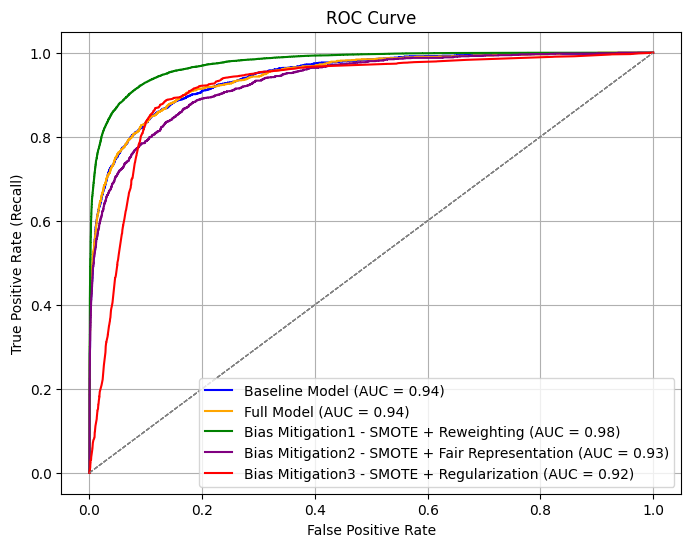

In [34]:
def plot_roc_auc(y_true, y_scores, label='Model', color='blue', ax=None):
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    auc_score = roc_auc_score(y_true, y_scores)

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 6))

    ax.plot(fpr, tpr, color=color, label=f'{label} (AUC = {auc_score:.2f})')
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=0.8)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate (Recall)')
    ax.set_title('ROC Curve')
    ax.grid(True)

    return auc_score, ax

fig, ax = plt.subplots(figsize=(8, 6))

auc_baseline, _ = plot_roc_auc(
    y_true=y_test_baseline,
    y_scores=y_proba_baseline,
    label='Baseline Model',
    color='blue',
    ax=ax
)

auc_full, _ = plot_roc_auc(
    y_true=y_test_full,
    y_scores=y_proba_full,
    label='Full Model',
    color='orange',
    ax=ax
)

auc_bm1, _ = plot_roc_auc(
    y_true=y_test_bm1,
    y_scores=y_proba_bm1,
    label='Bias Mitigation1 - SMOTE + Reweighting',
    color='green',
    ax=ax
)

auc_bm2, _ = plot_roc_auc(
    y_true=y_test_bm2,
    y_scores=y_proba_bm2,
    label='Bias Mitigation2 - SMOTE + Fair Representation',
    color='purple',
    ax=ax
)

auc_bm3, _ = plot_roc_auc(
    y_true=y_test_bm3,
    y_scores=y_proba_bm3,
    label='Bias Mitigation3 - SMOTE + Regularization',
    color='red',
    ax=ax
)

ax.legend()
plt.show()


Baseline Model (No Sensitive Features)
Best threshold based on F1 score: 0.352
Precision: 0.769, Recall: 0.632, F1: 0.694

Full Model (With Sensitive Features)
Best threshold based on F1 score: 0.354
Precision: 0.758, Recall: 0.644, F1: 0.696

Bias Mitigation1 - SMOTE + Reweighting
Best threshold based on F1 score: 0.663
Precision: 0.912, Recall: 0.921, F1: 0.917

Bias Mitigation2 - SMOTE + Fair Representation
Best threshold based on F1 score: 0.827
Precision: 0.732, Recall: 0.606, F1: 0.663

Bias Mitigation3 -  SMOTE + Regularization
Best threshold based on F1 score: 0.375
Precision: 0.867, Recall: 0.887, F1: 0.877


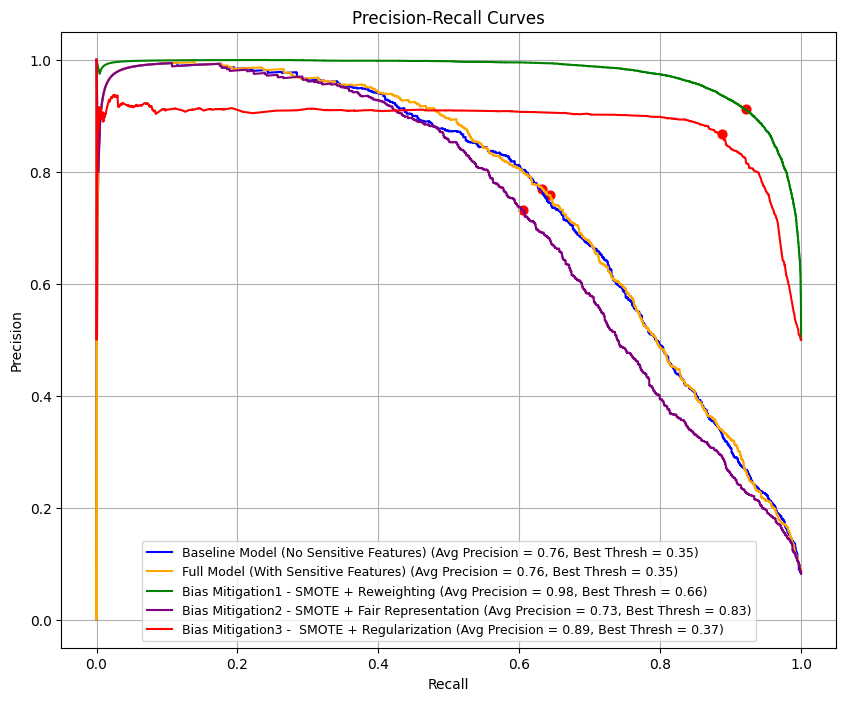

In [35]:
def plot_pr_and_find_best_threshold(y_true, y_scores, label='Model', color='black', ax=None):
    precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
    auc_score = roc_auc_score(y_true, y_scores)
    ap_score = average_precision_score(y_true, y_scores)
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]

    ax.plot(recall, precision, color=color, label=f'{label} (Avg Precision = {ap_score:.2f}, Best Thresh = {best_threshold:.2f})')
    ax.scatter(recall[best_idx], precision[best_idx], color='red', s=40)
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title('Precision-Recall Curve')
    ax.grid(True)

    print(f"\n{label}")
    print(f"Best threshold based on F1 score: {best_threshold:.3f}")
    print(f"Precision: {precision[best_idx]:.3f}, Recall: {recall[best_idx]:.3f}, F1: {best_f1:.3f}")

    y_pred = (y_scores >= best_threshold).astype(int)
    return best_threshold, y_pred, auc_score, best_f1, ax


fig, ax = plt.subplots(figsize=(10, 8))


best_thresh_baseline, y_pred_baseline, auc_baseline, best_f1_baseline, ax = plot_pr_and_find_best_threshold(
    y_true=y_test_baseline,
    y_scores=y_proba_baseline,
    label='Baseline Model (No Sensitive Features)',
    color='blue',
    ax=ax
)

best_thresh_full, y_pred_full, auc_full, best_f1_full, ax = plot_pr_and_find_best_threshold(
    y_true=y_test_full,
    y_scores=y_proba_full,
    label='Full Model (With Sensitive Features)',
    color='orange',
    ax=ax
)


best_thresh_bm1, y_pred_bm1, auc_bm1, best_f1_bm1, ax = plot_pr_and_find_best_threshold(
    y_true=y_test_bm1,
    y_scores=y_proba_bm1,
    label='Bias Mitigation1 - SMOTE + Reweighting',
    color='green',
    ax=ax
)


best_thresh_bm2, y_pred_bm2, auc_bm2, best_f1_bm2, ax = plot_pr_and_find_best_threshold(
    y_true=y_test_bm2,
    y_scores=y_proba_bm2,
    label='Bias Mitigation2 - SMOTE + Fair Representation',
    color='purple',
    ax=ax
)


best_thresh_bm3, y_pred_bm3, auc_bm3, best_f1_bm3, ax = plot_pr_and_find_best_threshold(
    y_true=y_test_bm3,
    y_scores=y_proba_bm3,
    label='Bias Mitigation3 -  SMOTE + Regularization',
    color='red',
    ax=ax
)


ax.legend(fontsize=9)
plt.title('Precision-Recall Curves')
plt.grid(True)
plt.show()

Baseline Model (No Sensitive Features)
              precision    recall  f1-score   support

           0      0.968     0.983     0.975     17339
           1      0.769     0.632     0.694      1550

    accuracy                          0.954     18889
   macro avg      0.868     0.808     0.835     18889
weighted avg      0.951     0.954     0.952     18889


AUC: 0.944

Full Model (With Sensitive Features)
              precision    recall  f1-score   support

           0      0.969     0.982     0.975     17339
           1      0.758     0.644     0.696      1550

    accuracy                          0.954     18889
   macro avg      0.863     0.813     0.836     18889
weighted avg      0.951     0.954     0.952     18889

AUC: 0.944

Bias Mitigation1 - SMOTE + Reweighting
              precision    recall  f1-score   support

           0      0.920     0.911     0.916     17338
           1      0.912     0.921     0.917     17339

    accuracy                          0.91

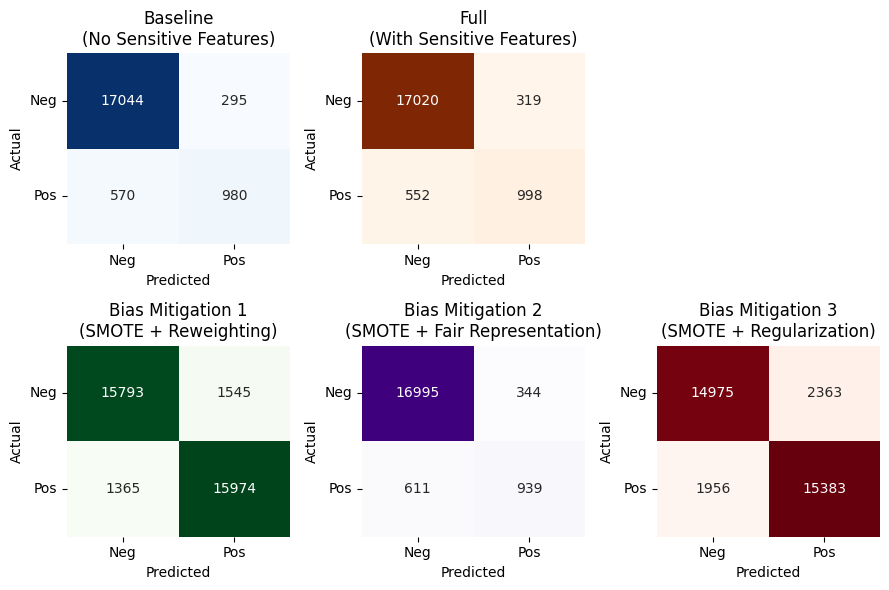

In [36]:
print("Baseline Model (No Sensitive Features)")
print(classification_report(y_test_baseline, y_pred_baseline, digits=3))
print(f"\nAUC: {auc_baseline:.3f}")

print("\nFull Model (With Sensitive Features)")
print(classification_report(y_test_full, y_pred_full, digits=3))
print(f"AUC: {auc_full:.3f}")

print("\nBias Mitigation1 - SMOTE + Reweighting")
print(classification_report(y_test_bm1, y_pred_bm1, digits=3))
print(f"AUC: {auc_bm1:.3f}")

print("\nBias Mitigation2 - SMOTE + Fair Representation")
print(classification_report(y_test_bm2, y_pred_bm2, digits=3))
print(f"AUC: {auc_bm2:.3f}")

print("\nBias Mitigation3 - SMOTE + Regularization")
print(classification_report(y_test_bm3, y_pred_bm3, digits=3))
print(f"AUC: {auc_bm3:.3f}")


cm_baseline = confusion_matrix(y_test_baseline, y_pred_baseline)
cm_full = confusion_matrix(y_test_full, y_pred_full)
cm_bm1 = confusion_matrix(y_test_bm1, y_pred_bm1)
cm_bm2 = confusion_matrix(y_test_bm2, y_pred_bm2)
cm_bm3 = confusion_matrix(y_test_bm3, y_pred_bm3)

fig, axs = plt.subplots(2, 3, figsize=(9, 6))
axs = axs.flatten()

# Baseline
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axs[0])
axs[0].set_title('Baseline\n(No Sensitive Features)')
axs[0].set_xlabel('Predicted')
axs[0].set_ylabel('Actual')
axs[0].set_xticklabels(['Neg', 'Pos'])
axs[0].set_yticklabels(['Neg', 'Pos'], rotation=0)

# Full
sns.heatmap(cm_full, annot=True, fmt='d', cmap='Oranges', cbar=False, ax=axs[1])
axs[1].set_title('Full\n(With Sensitive Features)')
axs[1].set_xlabel('Predicted')
axs[1].set_ylabel('Actual')
axs[1].set_xticklabels(['Neg', 'Pos'])
axs[1].set_yticklabels(['Neg', 'Pos'], rotation=0)

axs[2].axis('off')

# BM1
sns.heatmap(cm_bm1, annot=True, fmt='d', cmap='Greens', cbar=False, ax=axs[3])
axs[3].set_title('Bias Mitigation 1\n(SMOTE + Reweighting)')
axs[3].set_xlabel('Predicted')
axs[3].set_ylabel('Actual')
axs[3].set_xticklabels(['Neg', 'Pos'])
axs[3].set_yticklabels(['Neg', 'Pos'], rotation=0)

# BM2
sns.heatmap(cm_bm2, annot=True, fmt='d', cmap='Purples', cbar=False, ax=axs[4])
axs[4].set_title('Bias Mitigation 2\n(SMOTE + Fair Representation)')
axs[4].set_xlabel('Predicted')
axs[4].set_ylabel('Actual')
axs[4].set_xticklabels(['Neg', 'Pos'])
axs[4].set_yticklabels(['Neg', 'Pos'], rotation=0)

# BM3
sns.heatmap(cm_bm3, annot=True, fmt='d', cmap='Reds', cbar=False, ax=axs[5])
axs[5].set_title('Bias Mitigation 3\n(SMOTE + Regularization)')
axs[5].set_xlabel('Predicted')
axs[5].set_ylabel('Actual')
axs[5].set_xticklabels(['Neg', 'Pos'])
axs[5].set_yticklabels(['Neg', 'Pos'], rotation=0)

plt.tight_layout()
plt.show()


#### Fairness Diagnosis

In [37]:
df_test_full = create_df_test(df, X_test_full, y_test_full, y_pred_full, y_proba_full)
df_test_baseline = create_df_test(df, X_test_baseline, y_test_baseline, y_pred_baseline, y_proba_baseline)
df_test_bm1 = create_df_test(df_resampled, X_test_bm1, y_test_bm1, y_pred_bm1, y_proba_bm1)

X_test_bm2 = pd.DataFrame(X_test_bm2, index=y_test_bm2.index)
df_test_bm2 = create_df_test(df_resampled, X_test_bm2, y_test_bm2, y_pred_bm2, y_proba_bm2)
df_test_bm3 = create_df_test(df_resampled, X_test_bm3, y_test_bm3, y_pred_bm3, y_proba_bm3)

gender_report_full = get_group_metrics(df_test_full, 'gender_group')
age_report_full = get_group_metrics(df_test_full, 'age_group')
race_report_full = get_group_metrics(df_test_full, 'race_group')

gender_report_baseline = get_group_metrics(df_test_baseline, 'gender_group')
age_report_baseline = get_group_metrics(df_test_baseline, 'age_group')
race_report_baseline = get_group_metrics(df_test_baseline, 'race_group')

gender_report_bm1 = get_group_metrics(df_test_bm1, 'gender_group')
age_report_bm1 = get_group_metrics(df_test_bm1, 'age_group')
race_report_bm1 = get_group_metrics(df_test_bm1, 'race_group')

gender_report_bm2 = get_group_metrics(df_test_bm2, 'gender_group')
age_report_bm2 = get_group_metrics(df_test_bm2, 'age_group')
race_report_bm2 = get_group_metrics(df_test_bm2, 'race_group')

gender_report_bm3 = get_group_metrics(df_test_bm3, 'gender_group')
age_report_bm3 = get_group_metrics(df_test_bm3, 'age_group')
race_report_bm3 = get_group_metrics(df_test_bm3, 'race_group')


gender_report_full['model'] = 'Full'
age_report_full['model'] = 'Full'
race_report_full['model'] = 'Full'

gender_report_baseline['model'] = 'Baseline'
age_report_baseline['model'] = 'Baseline'
race_report_baseline['model'] = 'Baseline'

gender_report_bm1['model'] = 'bm1'
age_report_bm1['model'] = 'bm1'
race_report_bm1['model'] = 'bm1'

gender_report_bm2['model'] = 'bm2'
age_report_bm2['model'] = 'bm2'
race_report_bm2['model'] = 'bm2'

gender_report_bm3['model'] = 'bm3'
age_report_bm3['model'] = 'bm3'
race_report_bm3['model'] = 'bm3'

gender_comparison = pd.concat([gender_report_full, gender_report_baseline, gender_report_bm1, gender_report_bm2, gender_report_bm3])
age_comparison = pd.concat([age_report_full, age_report_baseline, age_report_bm1, age_report_bm2, age_report_bm3])
race_comparison = pd.concat([race_report_full, race_report_baseline, race_report_bm1, race_report_bm2, race_report_bm3])

gender_comparison
age_comparison
race_comparison

,group,support,precision,recall (TPR),f1_score,FPR,PPR,model
0,WHITE,867.0,0.779710,0.620531,0.691073,0.013879,0.058381,Full
1,OTHER,61.0,0.704918,0.704918,0.704918,0.023778,0.074572,Full
2,UNKNOWN,329.0,0.789655,0.696049,0.739903,0.032309,0.130807,Full
3,BLACK,141.0,0.666667,0.609929,0.637037,0.022108,0.061841,Full
4,HISPANIC/LATINO,52.0,0.720000,0.692308,0.705882,0.022117,0.072993,Full
5,ASIAN,53.0,0.727273,0.754717,0.740741,0.029014,0.096491,Full
6,EUROPEAN,29.0,0.538462,0.482759,0.509091,0.024691,0.050485,Full
7,RUSSIAN,18.0,0.750000,0.666667,0.705882,0.024845,0.089385,Full
0,WHITE,867.0,0.775281,0.636678,0.699177,0.014609,0.060242,Baseline
1,OTHER,61.0,0.724138,0.688525,0.705882,0.021136,0.070905,Baseline


#### Equal Opportunity  

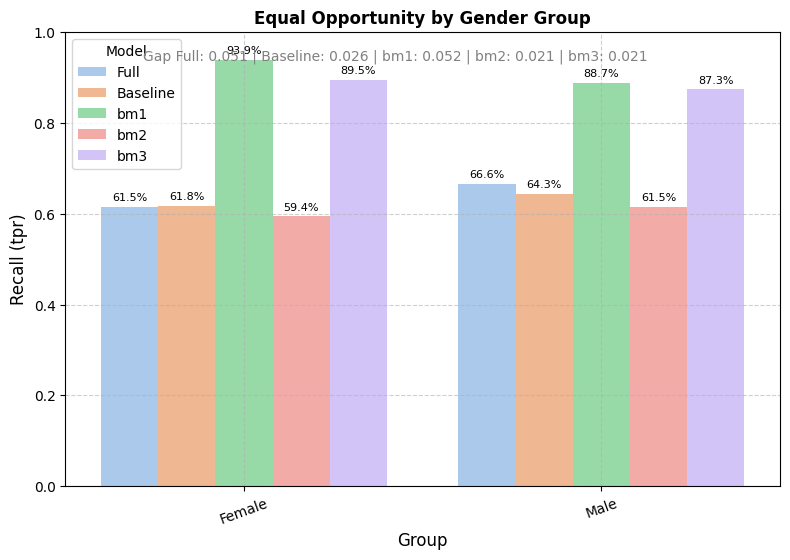

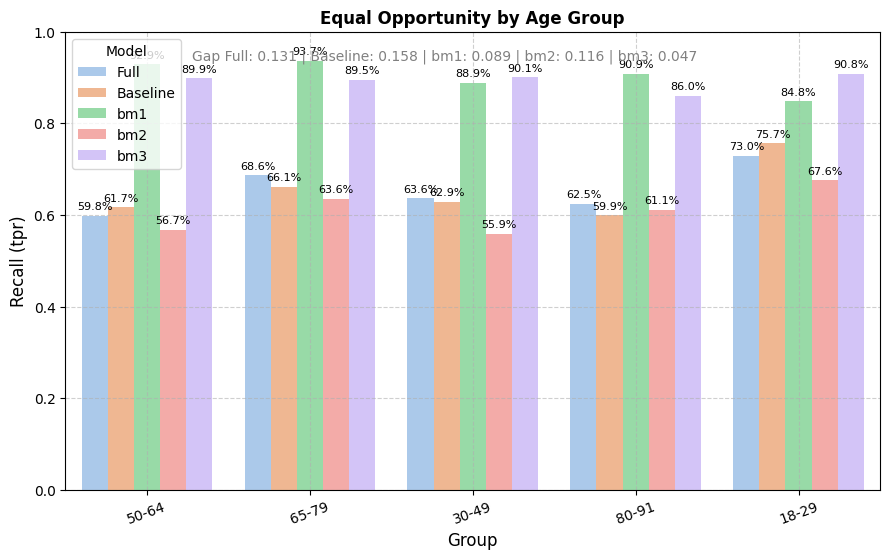

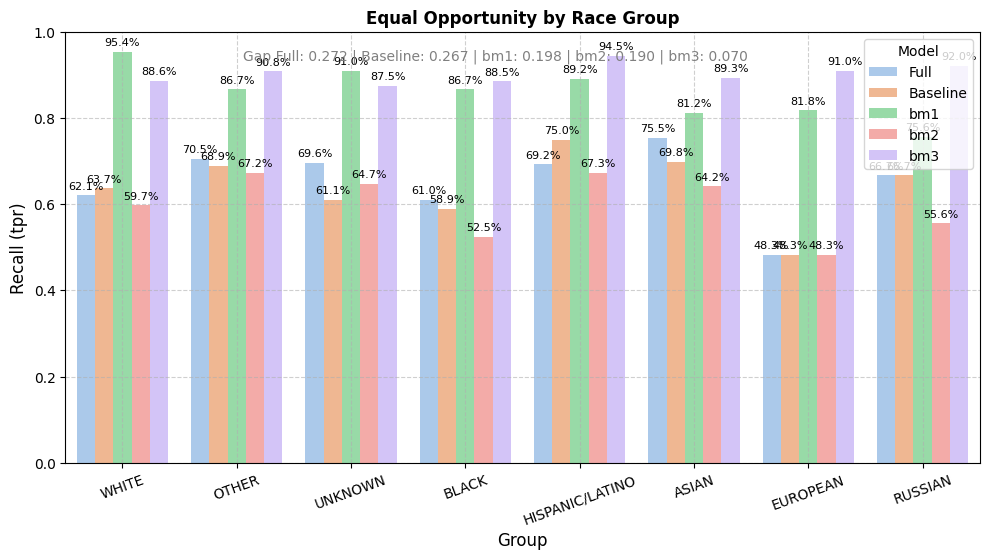

In [38]:
gender_eo_dict = plot_equal_opportunity(gender_comparison, metric='recall (TPR)', title='Equal Opportunity by Gender Group', figsize=(8, 6))
age_eo_dict = plot_equal_opportunity(age_comparison, metric='recall (TPR)', title='Equal Opportunity by Age Group', figsize=(9, 6))
race_eo_dict = plot_equal_opportunity(race_comparison, metric='recall (TPR)', title='Equal Opportunity by Race Group', figsize=(10, 6))

#### Statistical Parity

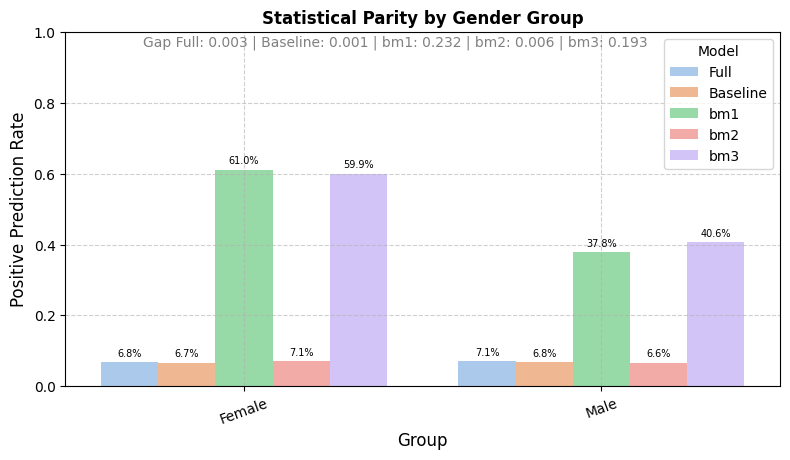

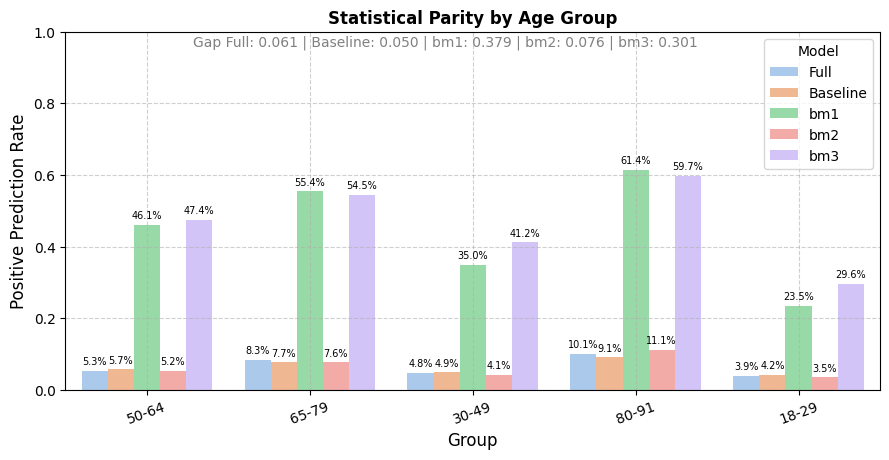

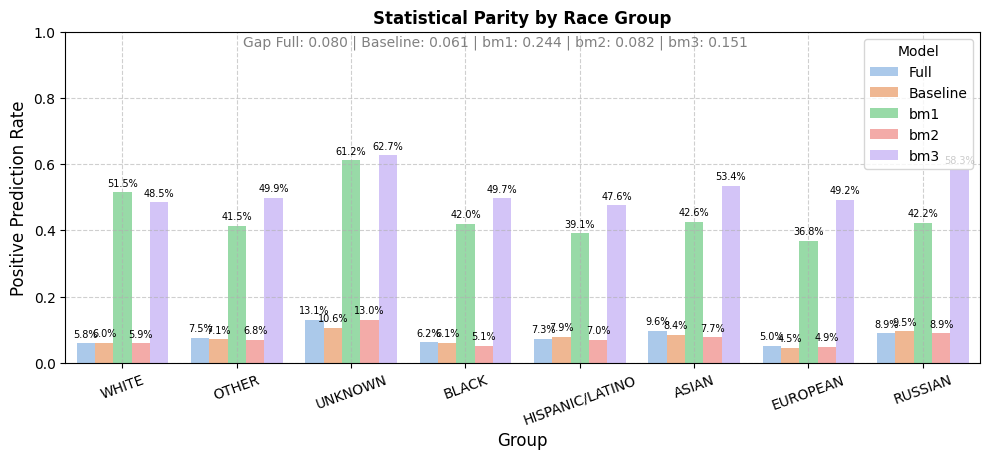

In [39]:
gender_ppr_dict = plot_statistical_parity(df=gender_comparison, title='Statistical Parity by Gender Group', figsize=(8, 5))
age_ppr_dict = plot_statistical_parity(df=age_comparison, title='Statistical Parity by Age Group', figsize=(9, 5))
race_ppr_dict = plot_statistical_parity(df=race_comparison, title='Statistical Parity by Race Group', figsize=(10, 5))

#### Equalized Odds

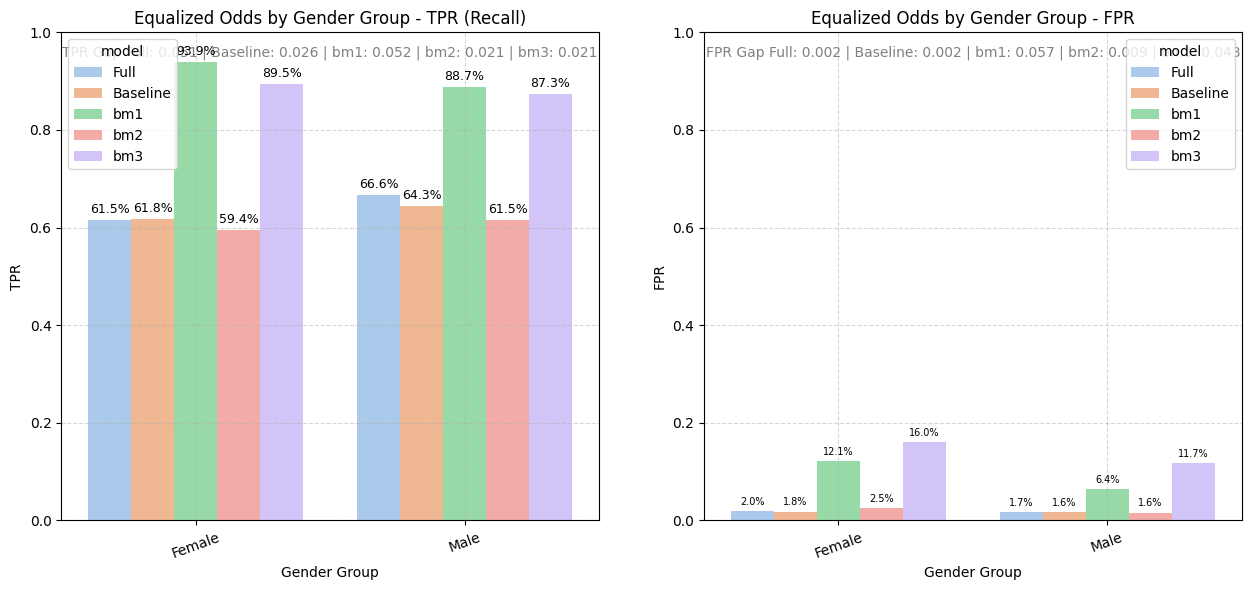

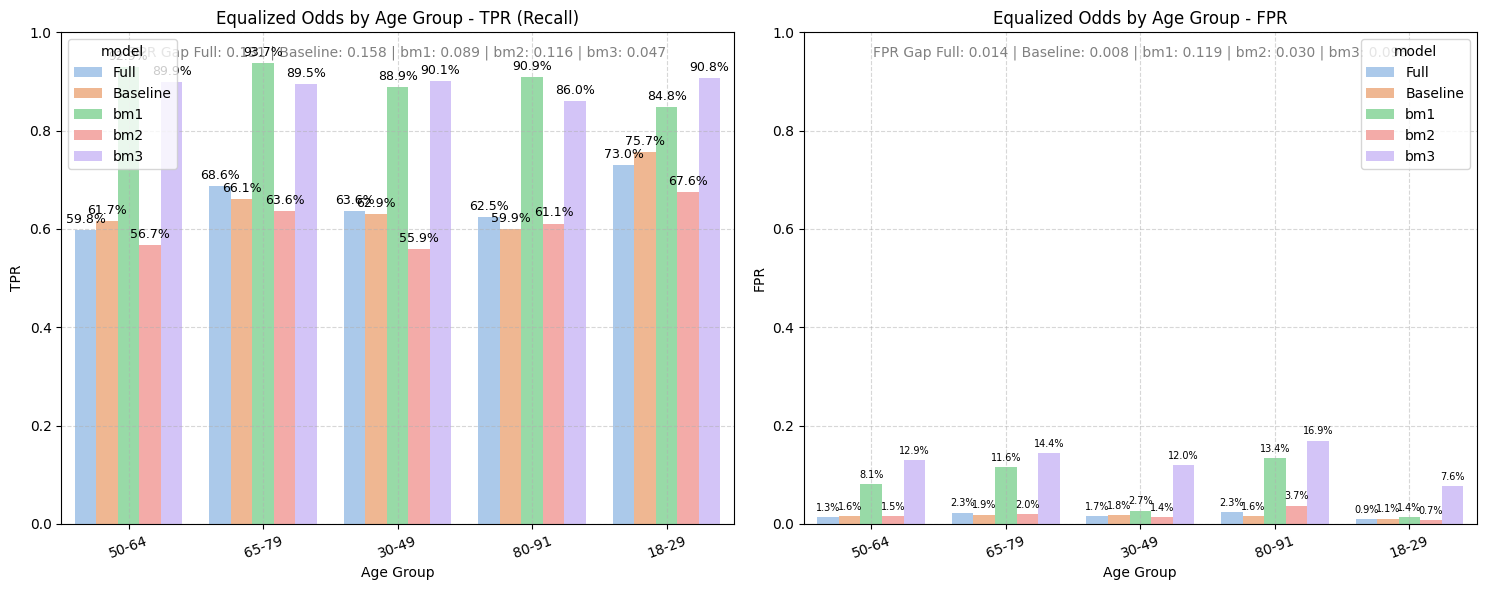

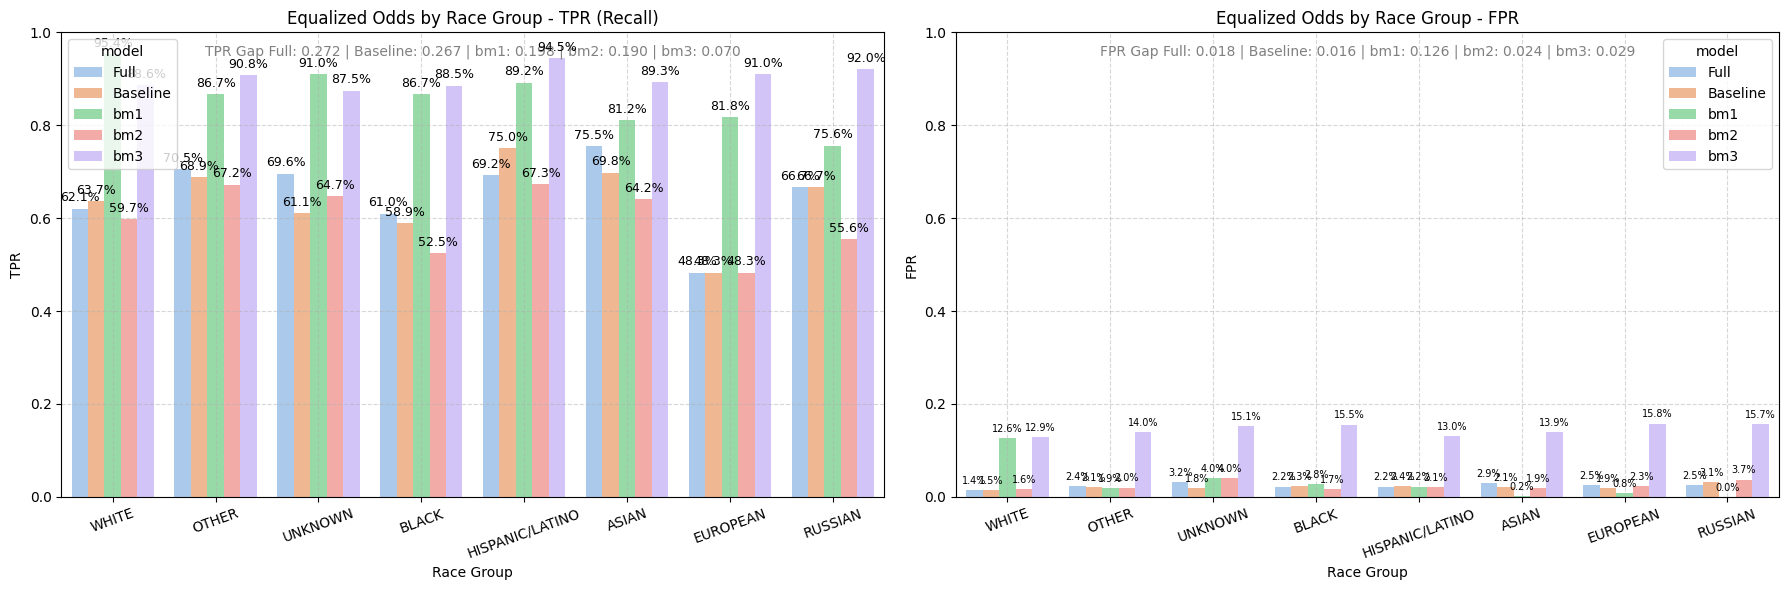

In [40]:
gender_tpr_dict, gender_fpr_dict = plot_equalized_odds(gender_comparison, group_col_name='Gender Group', title_prefix='Equalized Odds by Gender Group', figsize=(13, 6))
age_tpr_dict, age_fpr_dict = plot_equalized_odds(age_comparison, group_col_name='Age Group', title_prefix='Equalized Odds by Age Group', figsize=(15, 6))
race_tpr_dict, race_fpr_dict = plot_equalized_odds(race_comparison, group_col_name='Race Group', title_prefix='Equalized Odds by Race Group', figsize=(18, 6))

#### Calibration

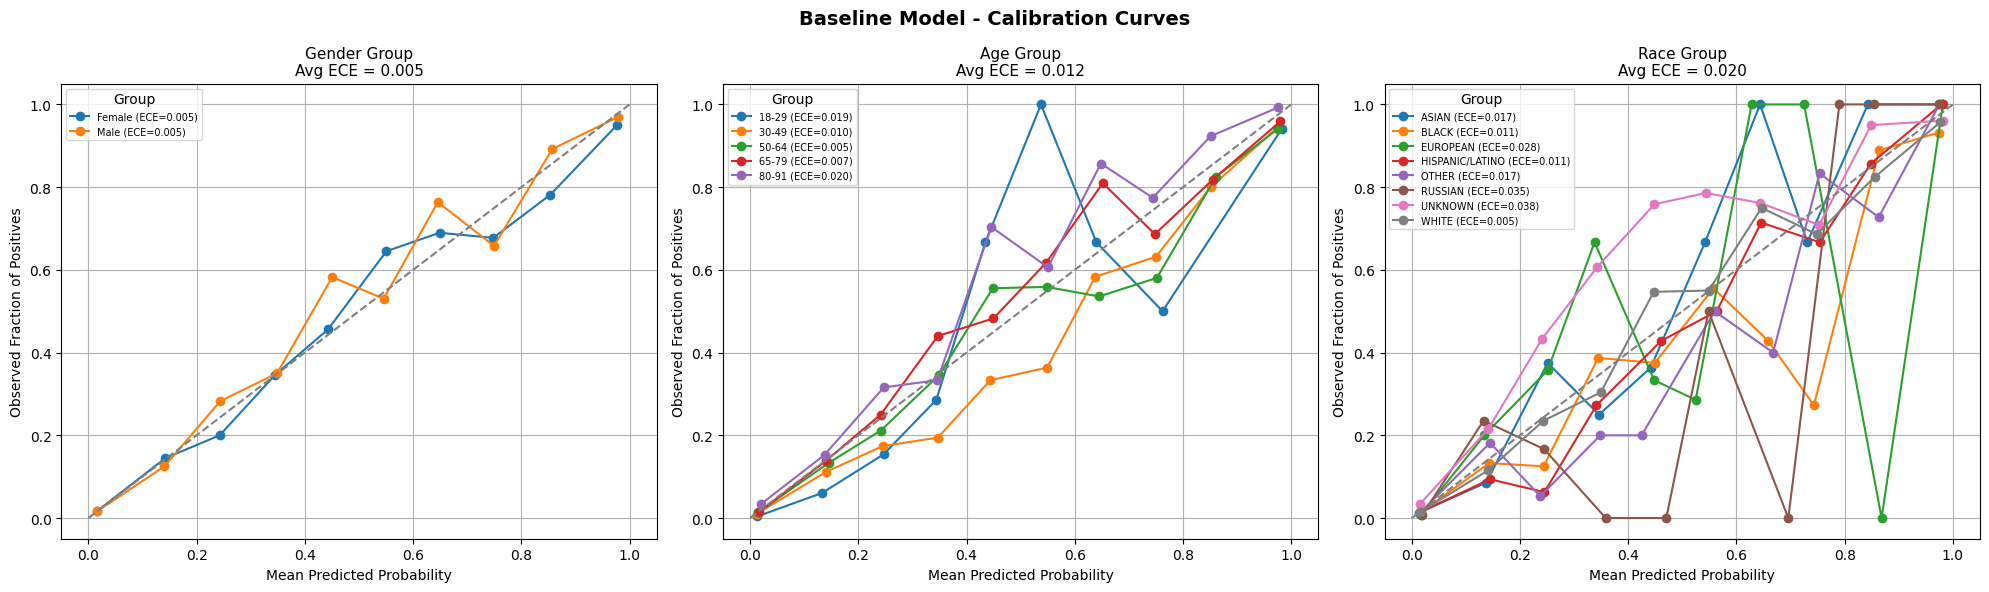

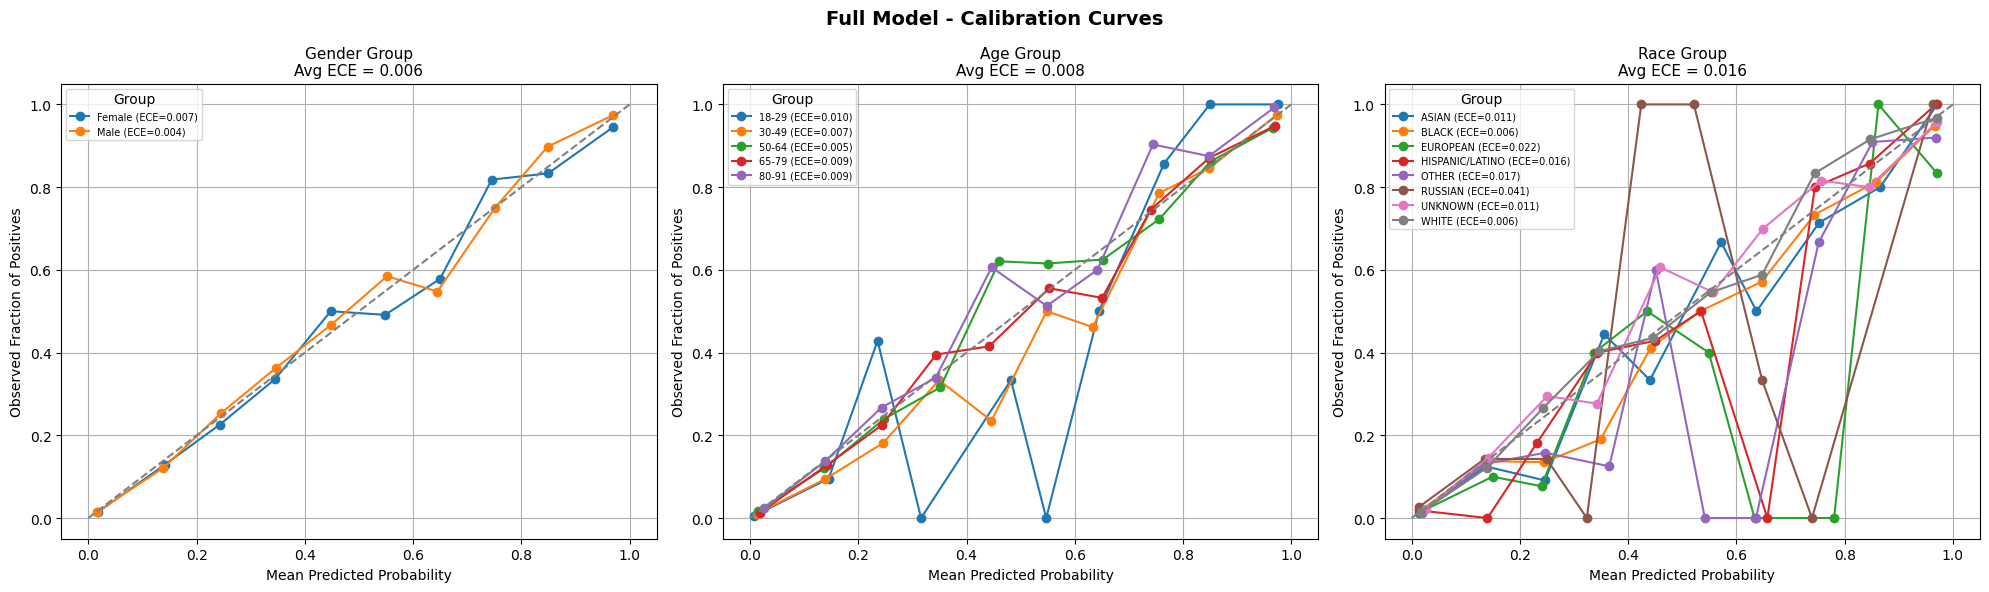

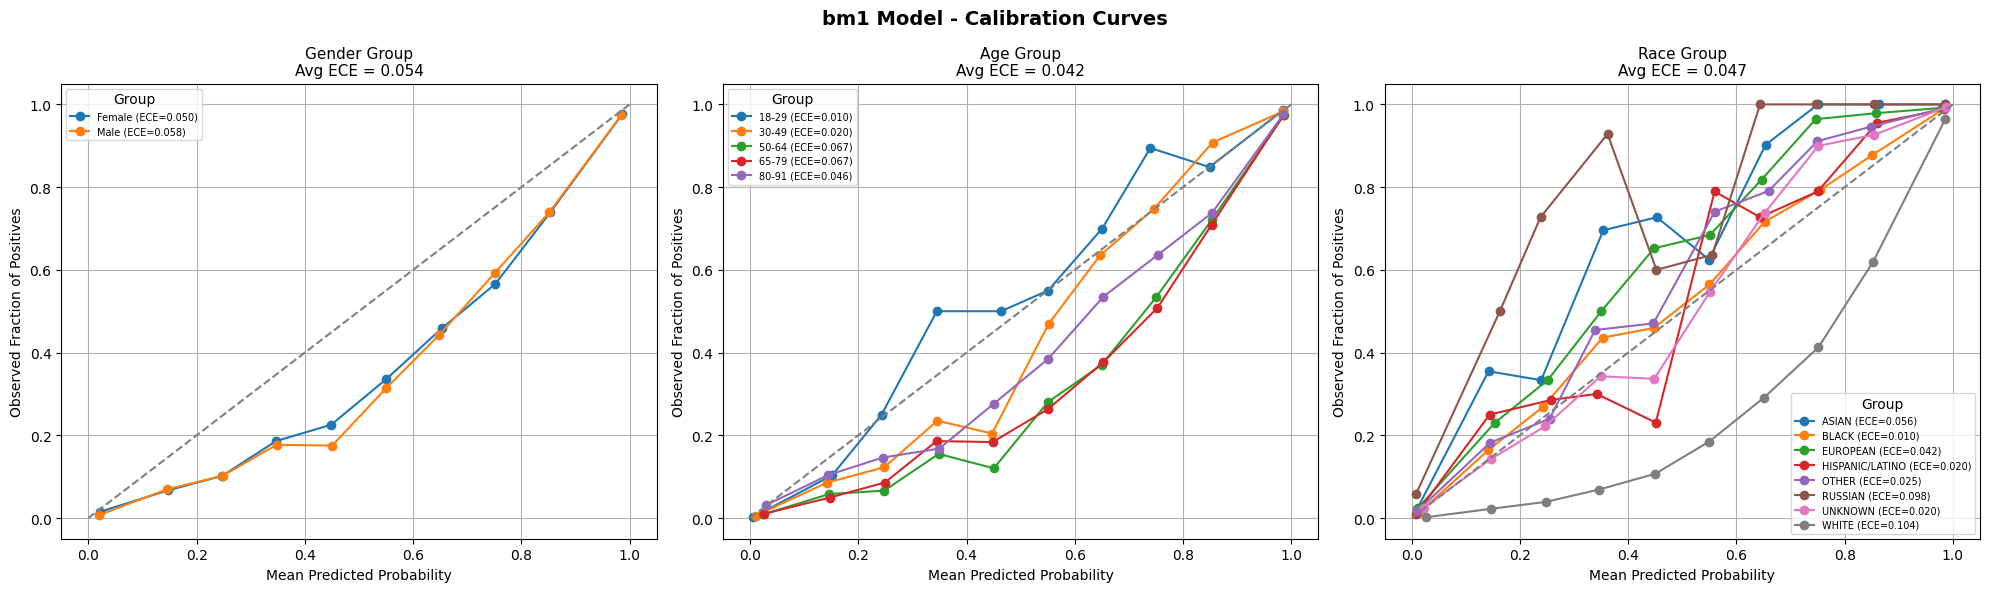

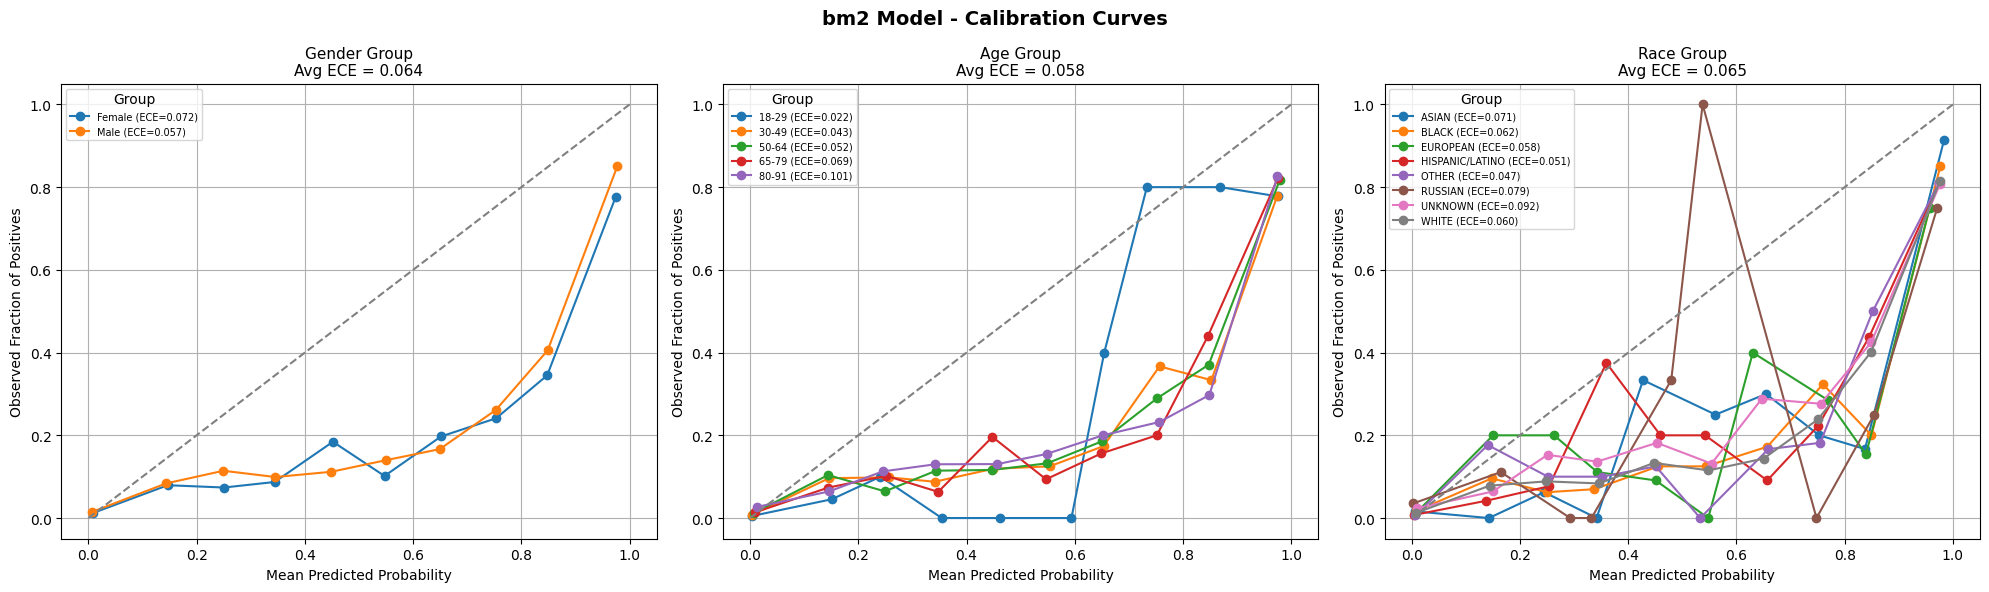

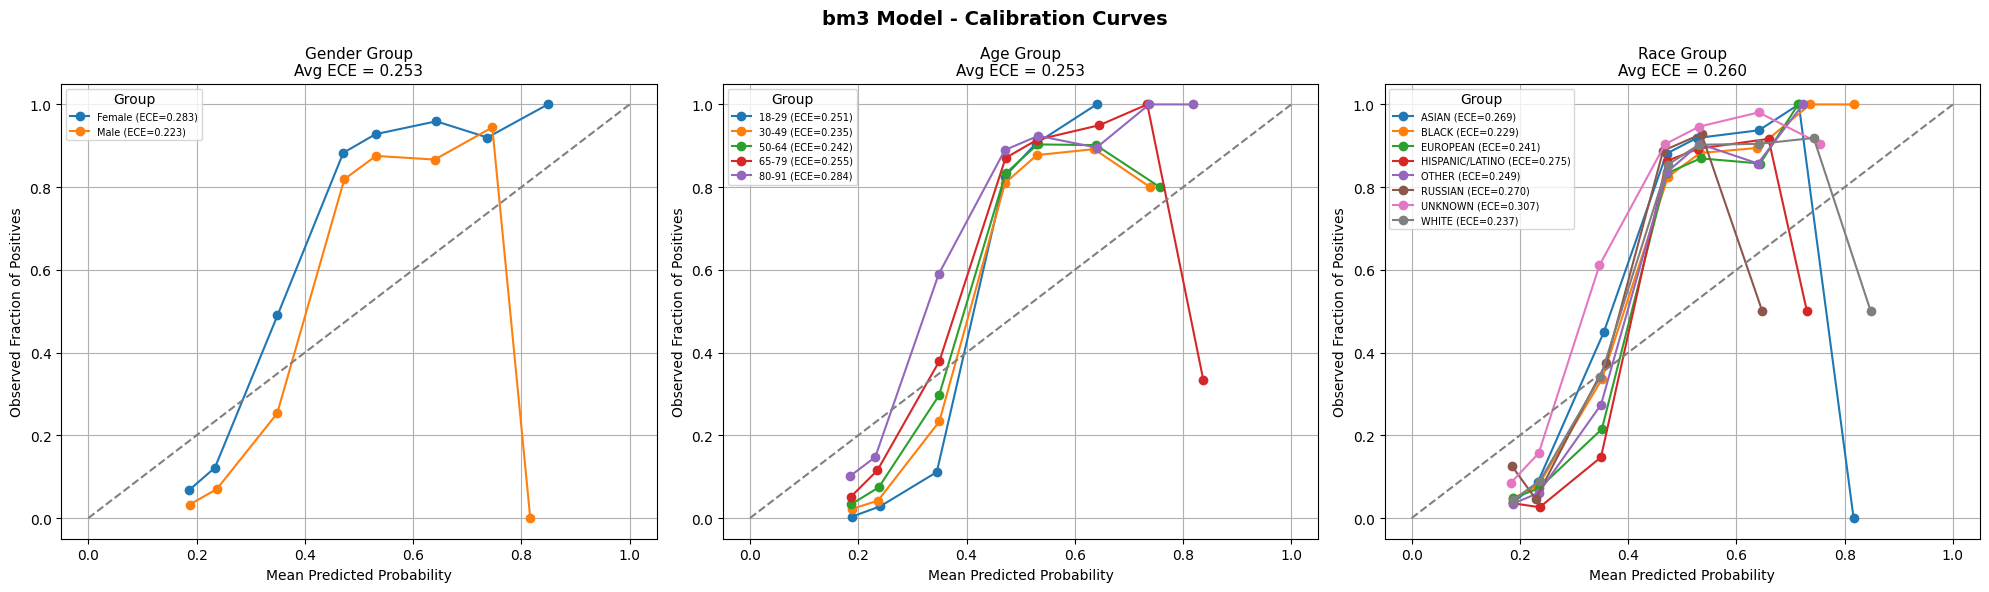

In [41]:
df_list = [df_test_baseline, df_test_full, df_test_bm1, df_test_bm2, df_test_bm3]
model_label = ['Baseline', 'Full', 'bm1', 'bm2', 'bm3']
avg_subgroup_ece = {}
for df_l, model_l in zip(df_list, model_label):
    avg_subgroup_ece[model_l] = plot_calibration_ece(df=df_l, model_label = model_l, figsize=(20, 6))


#### 	Fairness-Performance Tradeoff Analysis

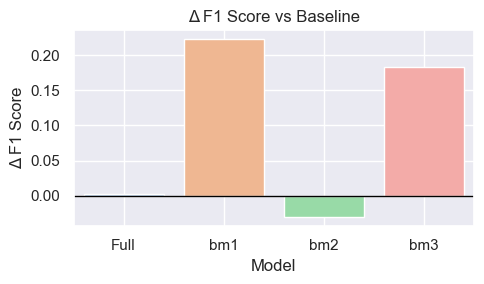

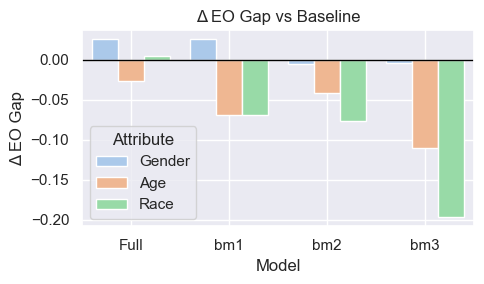

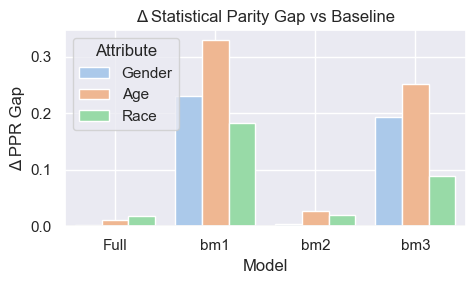

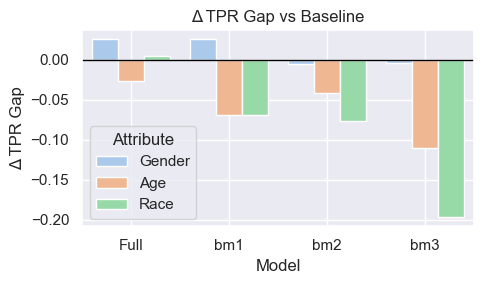

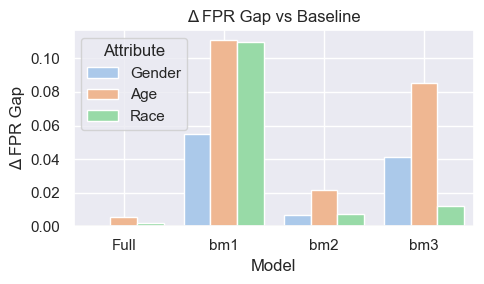

In [42]:
models = ['Full', 'bm1', 'bm2', 'bm3']

f1_deltas = [best_f1_full - best_f1_baseline,
             best_f1_bm1 - best_f1_baseline,
             best_f1_bm2 - best_f1_baseline,
             best_f1_bm3 - best_f1_baseline]

gender_eo_deltas = [gender_eo_dict[model] - gender_eo_dict['Baseline'] for model in models]
age_eo_deltas = [age_eo_dict[model] - age_eo_dict['Baseline'] for model in models]
race_eo_deltas = [race_eo_dict[model] - race_eo_dict['Baseline'] for model in models]

gender_ppr_deltas = [gender_ppr_dict[model] - gender_ppr_dict['Baseline'] for model in models]
age_ppr_deltas = [age_ppr_dict[model] - age_ppr_dict['Baseline'] for model in models]
race_ppr_deltas = [race_ppr_dict[model] - race_ppr_dict['Baseline'] for model in models]

gender_tpr_deltas = [gender_tpr_dict[model] - gender_tpr_dict['Baseline'] for model in models]
age_tpr_deltas    = [age_tpr_dict[model] - age_tpr_dict['Baseline'] for model in models]
race_tpr_deltas   = [race_tpr_dict[model] - race_tpr_dict['Baseline'] for model in models]

gender_fpr_deltas = [gender_fpr_dict[model] - gender_fpr_dict['Baseline'] for model in models]
age_fpr_deltas    = [age_fpr_dict[model] - age_fpr_dict['Baseline'] for model in models]
race_fpr_deltas   = [race_fpr_dict[model] - race_fpr_dict['Baseline'] for model in models]


df_f1 = pd.DataFrame({
    'Model': models,
    'Δ F1 Score': f1_deltas
})

df_eo = pd.DataFrame({
    'Model': models * 3,
    'Attribute': ['Gender'] * 4 + ['Age'] * 4 + ['Race'] * 4,
    'Δ EO Gap': gender_eo_deltas + age_eo_deltas + race_eo_deltas
})


df_ppr = pd.DataFrame({
    'Model': models * 3,
    'Attribute': ['Gender'] * 4 + ['Age'] * 4 + ['Race'] * 4,
    'Δ PPR Gap': gender_ppr_deltas + age_ppr_deltas + race_ppr_deltas
})


df_tpr = pd.DataFrame({
    'Model': models * 3,
    'Attribute': ['Gender'] * 4 + ['Age'] * 4 + ['Race'] * 4,
    'Δ TPR Gap': gender_tpr_deltas + age_tpr_deltas + race_tpr_deltas
})


df_fpr = pd.DataFrame({
    'Model': models * 3,
    'Attribute': ['Gender'] * 4 + ['Age'] * 4 + ['Race'] * 4,
    'Δ FPR Gap': gender_fpr_deltas + age_fpr_deltas + race_fpr_deltas
})

sns.set(style="darkgrid")

plt.figure(figsize=(5, 3))
sns.barplot(x='Model', y='Δ F1 Score', hue='Model', data=df_f1, palette='pastel')
plt.axhline(0, color='black', linewidth=1)
plt.title('Δ F1 Score vs Baseline')
plt.grid(True)
plt.tight_layout()
plt.show()


plt.figure(figsize=(5, 3))
sns.barplot(x='Model', y='Δ EO Gap', hue='Attribute', data=df_eo, palette='pastel')
plt.axhline(0, color='black', linewidth=1)
plt.title('Δ EO Gap vs Baseline')
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 3))
sns.barplot(x='Model', y='Δ PPR Gap', hue='Attribute', data=df_ppr, palette='pastel')
plt.axhline(0, color='black', linewidth=1)
plt.title('Δ Statistical Parity Gap vs Baseline')
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 3))
sns.barplot(x='Model', y='Δ TPR Gap', hue='Attribute', data=df_tpr, palette='pastel')
plt.axhline(0, color='black', linewidth=1)
plt.title('Δ TPR Gap vs Baseline')
plt.grid(True)
plt.tight_layout()
plt.show()


plt.figure(figsize=(5, 3))
sns.barplot(x='Model', y='Δ FPR Gap', hue='Attribute', data=df_fpr, palette='pastel')
plt.axhline(0, color='black', linewidth=1)
plt.title('Δ FPR Gap vs Baseline')
plt.grid(True)
plt.tight_layout()
plt.show()

In [43]:
models = ['Full', 'Baseline', 'bm1', 'bm2', 'bm3']
gender_fairness_df = pd.DataFrame({
    'Model': models,
    'Attribute': ['Gender'] * len(models),
    'PPR Gap': [gender_ppr_dict[model] for model in models], # statistical parity gap
    'TPR Gap': [gender_tpr_dict[model] for model in models], # equal opportunity gap
    'FPR Gap': [gender_fpr_dict[model] for model in models], # equalized odds gap (omit tpr)
    'ECE': [avg_subgroup_ece[model]['gender_group'] for model in models],
    'F1 Score': [best_f1_full, best_f1_baseline, best_f1_bm1, best_f1_bm2, best_f1_bm3]
})

# Normalize the fairness gaps to create an index bounded between 0 and 1
gender_fairness_df['Fairness Total'] = gender_fairness_df[['PPR Gap', 'TPR Gap', 'FPR Gap', 'ECE']].sum(axis=1)
gender_fairness_df['Fairness Index'] = 1 / (1 + gender_fairness_df['Fairness Total'])
gender_fairness_df


age_fairness_df = pd.DataFrame({
    'Model': models,
    'Attribute': ['Age'] * len(models),
    'PPR Gap': [age_ppr_dict[model] for model in models], # statistical parity gap
    'TPR Gap': [age_tpr_dict[model] for model in models], # equal opportunity gap
    'FPR Gap': [age_fpr_dict[model] for model in models], # equalized odds gap (omit tpr)
    'ECE': [avg_subgroup_ece[model]['age_group'] for model in models],
    'F1 Score': [best_f1_full, best_f1_baseline, best_f1_bm1, best_f1_bm2, best_f1_bm3]
})

# Normalize the fairness gaps to create an index bounded between 0 and 1
age_fairness_df['Fairness Total'] = age_fairness_df[['PPR Gap', 'TPR Gap', 'FPR Gap', 'ECE']].sum(axis=1)
age_fairness_df['Fairness Index'] = 1 / (1 + age_fairness_df['Fairness Total'])
age_fairness_df


race_fairness_df = pd.DataFrame({
    'Model': models,
    'Attribute': ['Race'] * len(models),
    'PPR Gap': [race_ppr_dict[model] for model in models], # statistical parity gap
    'TPR Gap': [race_tpr_dict[model] for model in models], # equal opportunity gap
    'FPR Gap': [race_fpr_dict[model] for model in models], # equalized odds gap (omit tpr)
    'ECE': [avg_subgroup_ece[model]['race_group'] for model in models],
    'F1 Score': [best_f1_full, best_f1_baseline, best_f1_bm1, best_f1_bm2, best_f1_bm3]
})

# Normalize the fairness gaps to create an index bounded between 0 and 1
race_fairness_df['Fairness Total'] = race_fairness_df[['PPR Gap', 'TPR Gap', 'FPR Gap', 'ECE']].sum(axis=1)
race_fairness_df['Fairness Index'] = 1 / (1 + race_fairness_df['Fairness Total'])
race_fairness_df

fairness_df = pd.concat([gender_fairness_df, age_fairness_df, race_fairness_df], ignore_index=True)
fairness_df

,Model,Attribute,PPR Gap,TPR Gap,FPR Gap,ECE,F1 Score,Fairness Total,Fairness Index
0,Full,Gender,0.003070,0.051471,0.002067,0.005551,0.696198,0.062158,0.941479
1,Baseline,Gender,0.001041,0.025651,0.001960,0.004735,0.693805,0.033387,0.967692
2,bm1,Gender,0.231595,0.051610,0.056787,0.054033,0.916518,0.394024,0.717348
3,bm2,Gender,0.005513,0.020783,0.008626,0.064356,0.662902,0.099278,0.909688
4,bm3,Gender,0.193385,0.021464,0.042928,0.252958,0.876899,0.510735,0.661929
5,Full,Age,0.061456,0.131284,0.013765,0.007923,0.696198,0.214428,0.823433
6,Baseline,Age,0.049582,0.157689,0.008131,0.012065,0.693805,0.227467,0.814686
7,bm1,Age,0.379246,0.088644,0.119312,0.042090,0.916518,0.629293,0.613763
8,bm2,Age,0.076179,0.116235,0.029926,0.057521,0.662902,0.279861,0.781335
9,bm3,Age,0.301404,0.047446,0.093195,0.253360,0.876899,0.695406,0.589829


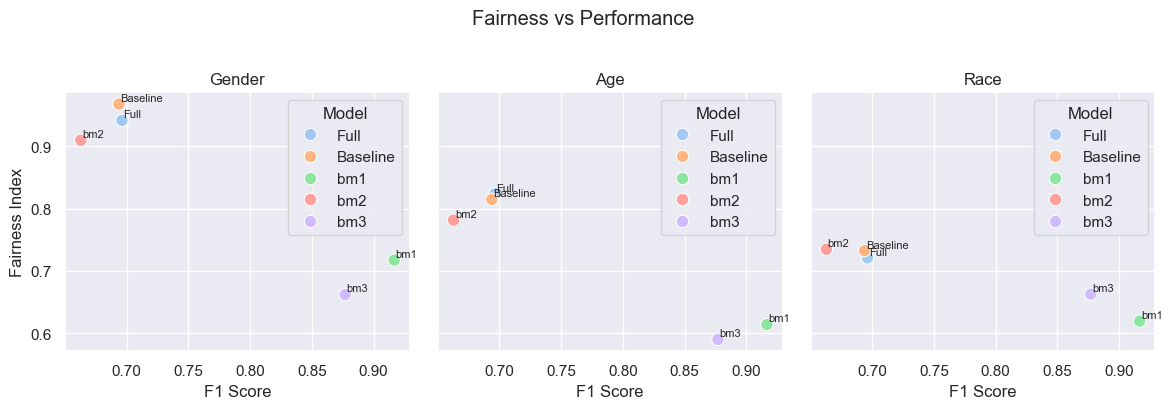

In [44]:
sns.set(style="darkgrid")
fig, axs = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

attributes = ['Gender', 'Age', 'Race']
for ax, attr in zip(axs, attributes):
    subset = fairness_df[fairness_df['Attribute'] == attr]
    
    sns.scatterplot(data=subset, x='F1 Score', y='Fairness Index', hue='Model', palette='pastel', s=80, ax=ax)
    fig.suptitle('Fairness vs Performance', y=1.02)
    for idx, row in subset.iterrows():
        ax.text(row['F1 Score'] + 0.001, row['Fairness Index'] + 0.005, row['Model'], fontsize=8)

    ax.set_title(f'{attr}')
    ax.set_xlabel('F1 Score')
    ax.set_ylabel('Fairness Index')
    ax.grid(True)
    ax.legend().set_title('Model')

plt.tight_layout()
plt.show()
